In [1]:
# CELL 1 — INSTALLS
!pip -q install pillow-heif facenet-pytorch pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.0 MB/s eta 0:00:00


In [12]:
# CELL 2 — IMPORTS AND CONFIG
import os, io, csv, gc, copy, random, hashlib
from pathlib import Path
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from pillow_heif import register_heif_opener
register_heif_opener(); ImageFile.LOAD_TRUNCATED_IMAGES=True

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b3
from facenet_pytorch import MTCNN
import pyarrow.parquet as pq

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
PIN_MEMORY=torch.cuda.is_available(); NUM_WORKERS=0
TARGET_SIZE=224; RESIZE_SIZE=256; FFT_CLIP_MAX=14.0
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
IMG_EXTS={'.jpg','.jpeg','.png','.webp','.bmp','.heic','.heif'}

FREQ_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model.pth')
ORIGINAL_SPATIAL_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth')
AUXILIARY_HEAD_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/spatial_auxiliary_multitask_head.pth')
STYLEGAN_ROOT=Path('/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train')
FLICKR_ROOT=Path('/kaggle/input/datasets/adityajn105/flickr30k/Images/flickr30k_images')
DEEPDETECT_ROOT=Path('/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train')
FF_SPLIT_ROOT=Path('/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split')
PHONE_ROOT=Path('/kaggle/input/datasets/kashirhanif/phone-images')
CELEB_ROOT=Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2')
OPENFAKE_DIRS=[Path(f'/kaggle/input/datasets/kashirhanif/openfake-part-{i}') for i in range(1,5)]
OPENFAKE_ROOT=Path('/kaggle/working/of_imgs'); OPENFAKE_MANIFEST=Path('/kaggle/working/of_manifest.csv')
OPENFAKE_PER_GENERATOR=1000
CAPS={'stylegan_real':25000,'stylegan_fake':25000,'flickr_real':15000,'deepdetect_fake':15000,'openfake_per_source':1000}
PHONE_TRAIN_RATIO=.60; PHONE_VAL_RATIO=.20
CELEB_REAL_CAP=10000; CELEB_FAKE_CAP=20000
FUSION_BATCH_SIZE=384; FUSION_EPOCHS=40; FUSION_LR=3e-4; FUSION_WEIGHT_DECAY=1e-4; FUSION_PATIENCE=7
PROJECTION_DIM=48; UNCERTAIN_LOW=.30; UNCERTAIN_HIGH=.70
OUTPUT_DIR=Path('/kaggle/working'); CACHE_PATH=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/heterogeneous_multiview_features.pt')
print('Device:',DEVICE)

Device: cuda


In [3]:
# CELL 3 — PATH CHECK
required={'frequency checkpoint':FREQ_CKPT,'spatial checkpoint':ORIGINAL_SPATIAL_CKPT,'auxiliary checkpoint':AUXILIARY_HEAD_CKPT,
          'StyleGAN':STYLEGAN_ROOT,'Flickr':FLICKR_ROOT,'DeepDetect':DEEPDETECT_ROOT,'FF++':FF_SPLIT_ROOT,
          'Phone':PHONE_ROOT,'CelebDF':CELEB_ROOT}
for name,path in required.items(): print(f'{name:<28}', 'OK' if path.exists() else 'MISSING', path)
missing=[name for name,path in required.items() if not path.exists()]
if missing: raise FileNotFoundError('Update paths in Cell 2: '+', '.join(missing))

frequency checkpoint         OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model.pth
spatial checkpoint           OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth
auxiliary checkpoint         OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/spatial_auxiliary_multitask_head.pth
StyleGAN                     OK /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train
Flickr                       OK /kaggle/input/datasets/adityajn105/flickr30k/Images/flickr30k_images
DeepDetect                   OK /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train
FF++                         OK /kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split
Phone                        OK /kaggle/input/datasets/kashirhanif/phone-images
CelebDF                      OK /kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2


In [4]:

# CELL 4 — REFERENCES AND SAFE HELPERS


from dataclasses import dataclass
from collections import defaultdict, Counter

@dataclass(frozen=True)
class SampleRef:
    path: str
    label: int
    source: str
    scenario: str
    spatial_mode: str      # already_face | detect | unavailable
    group: str = ""


def list_images(root: Path):
    if not root.exists():
        return []

    return sorted([
        p
        for p in root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMG_EXTS
    ])


def validate_image(path: Path):
    try:
        with Image.open(path) as image:
            image.load()
            image.convert("RGB")
        return True, ""
    except Exception as exc:
        return False, str(exc)


def cap_shuffle(paths, cap=None, seed=SEED):
    paths = list(paths)
    random.Random(seed).shuffle(paths)

    if cap is None:
        return paths

    return paths[:cap]


def group_key(path: Path):
    tokens = path.stem.replace("-", "_").split("_")

    if len(tokens) >= 2:
        return "_".join(tokens[:2])

    return path.stem


def make_refs(paths, label, source, scenario, spatial_mode):
    return [
        SampleRef(
            path=str(path),
            label=label,
            source=source,
            scenario=scenario,
            spatial_mode=spatial_mode,
            group=group_key(path),
        )
        for path in paths
    ]


def split_grouped_by_count(
    refs,
    train_ratio,
    val_ratio,
    seed=SEED,
):
    groups = defaultdict(list)

    for ref in refs:
        groups[ref.group].append(ref)

    items = list(groups.items())

    random.Random(seed).shuffle(items)

    items.sort(
        key=lambda x: len(x[1]),
        reverse=True,
    )

    total = len(refs)

    targets = {
        "train": int(total * train_ratio),
        "val": int(total * val_ratio),
        "test": (
            total
            - int(total * train_ratio)
            - int(total * val_ratio)
        ),
    }

    result = {
        "train": [],
        "val": [],
        "test": [],
    }

    for _, group_refs in items:

        deficits = {
            split: (
                targets[split]
                - len(result[split])
            )
            for split in result
        }

        chosen_split = max(
            result,
            key=lambda split:
                deficits[split]
                / max(targets[split], 1),
        )

        result[chosen_split].extend(group_refs)

    return result


def summarize(name, refs):

    print()
    print(f"{name}: {len(refs):,}")

    print(
        "labels:",
        Counter(r.label for r in refs),
    )

    print(
        "scenarios:",
        Counter(r.scenario for r in refs),
    )

    print(
        "spatial modes:",
        Counter(r.spatial_mode for r in refs),
    )

    print(
        "sources:",
        Counter(r.source for r in refs).most_common(12),
    )

In [5]:
# CELL 5 — LOAD THREE EXPERTS 
def trusted_load(path): return torch.load(path,map_location='cpu',weights_only=False)
def build_binary_efficientnet():
    m=efficientnet_b3(weights=None); n=m.classifier[1].in_features
    m.classifier=nn.Sequential(nn.Dropout(.3,inplace=True),nn.Linear(n,1)); return m

def unpack_state_dict(x):
    if not isinstance(x,dict): return x
    for k in ('model_state_dict','state_dict','model'):
        if k in x and isinstance(x[k],dict): return x[k]
    return x

def clean_state_dict(state):
    out={}
    for k,v in state.items():
        for prefix in ('module.','model.'):
            if k.startswith(prefix): k=k[len(prefix):]
        out[k]=v
    return out

def load_binary(path):
    m=build_binary_efficientnet(); ck=trusted_load(path); m.load_state_dict(clean_state_dict(unpack_state_dict(ck)),strict=True)
    m.to(DEVICE).eval(); [p.requires_grad_(False) for p in m.parameters()]; return m

class SpatialAuxiliaryHead(nn.Module):
    def __init__(self,input_dim,num_classes):
        super().__init__(); self.shared_trunk=nn.Sequential(nn.Linear(input_dim,512),nn.BatchNorm1d(512),nn.GELU(),nn.Dropout(.35),nn.Linear(512,128),nn.BatchNorm1d(128),nn.GELU(),nn.Dropout(.2)); self.binary_head=nn.Linear(128,1); self.auxiliary_head=nn.Linear(128,num_classes)
    def forward(self,x):
        z=self.shared_trunk(x); return {'binary_logit':self.binary_head(z).squeeze(1),'auxiliary_logits':self.auxiliary_head(z)}

freq_model=load_binary(FREQ_CKPT); original_spatial_model=load_binary(ORIGINAL_SPATIAL_CKPT)
freq_backbone=copy.deepcopy(freq_model); freq_backbone.classifier=nn.Identity(); freq_backbone.eval()
spatial_backbone=copy.deepcopy(original_spatial_model); spatial_backbone.classifier=nn.Identity(); spatial_backbone.eval()
aux_ck=trusted_load(AUXILIARY_HEAD_CKPT); aux_dim=int(aux_ck.get('embedding_dim',1536)); aux_names=aux_ck.get('aux_class_names',['real','fake']); aux_n=int(aux_ck.get('num_aux_classes',len(aux_names)))
aux_model=SpatialAuxiliaryHead(aux_dim,aux_n); aux_state=aux_ck.get('model_state_dict',aux_ck.get('state_dict'))
if aux_state is None: raise KeyError(f'No aux state dict. Keys={list(aux_ck)}')
aux_model.load_state_dict(clean_state_dict(aux_state),strict=True); aux_model.to(DEVICE).eval(); [p.requires_grad_(False) for p in aux_model.parameters()]
aux_mean=torch.nan_to_num(torch.as_tensor(aux_ck['feature_mean']).float(),nan=0,posinf=0,neginf=0)
aux_std=torch.nan_to_num(torch.as_tensor(aux_ck['feature_std']).float(),nan=1,posinf=1,neginf=1).clamp_min(1e-6)
print('Experts loaded.')

Experts loaded.


In [6]:
# CELL 6 — FULL-IMAGE FREQUENCY VIEW + FACE-LOCAL SPATIAL VIEW
spatial_transform=transforms.Compose([transforms.Resize((RESIZE_SIZE,RESIZE_SIZE)),transforms.CenterCrop(TARGET_SIZE),transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])

def preprocess_frequency_full(image):
    image=image.convert('RGB').resize((RESIZE_SIZE,RESIZE_SIZE),Image.Resampling.BICUBIC); o=(RESIZE_SIZE-TARGET_SIZE)//2; image=image.crop((o,o,o+TARGET_SIZE,o+TARGET_SIZE))
    arr=np.asarray(image,dtype=np.float32)/255.; x=torch.from_numpy(arr).permute(2,0,1); out=[]
    for c in x:
        f=torch.fft.fftshift(torch.fft.fft2(c)); mag=torch.log1p(torch.abs(f)); out.append(torch.clamp(mag,0,FFT_CLIP_MAX)/FFT_CLIP_MAX)
    return torch.stack(out)

mtcnn=MTCNN(keep_all=True,device=DEVICE,min_face_size=24,thresholds=[.6,.7,.7],post_process=False)

def square_crop(image,box,margin=.25):
    W,H=image.size; x1,y1,x2,y2=map(float,box); bw,bh=x2-x1,y2-y1; side=max(bw,bh)*(1+2*margin); cx,cy=(x1+x2)/2,(y1+y2)/2
    l=max(0,int(cx-side/2)); t=max(0,int(cy-side/2)); r=min(W,int(cx+side/2)); b=min(H,int(cy+side/2)); return image.crop((l,t,r,b))

def get_spatial_view(image,mode):
    if mode=='already_face': return {'crop':image,'found':1.,'confidence':1.,'count':1.,'area_ratio':1.}
    if mode=='unavailable': return {'crop':None,'found':0.,'confidence':0.,'count':0.,'area_ratio':0.}
    boxes,probs=mtcnn.detect(image)
    if boxes is None or len(boxes)==0: return {'crop':None,'found':0.,'confidence':0.,'count':0.,'area_ratio':0.}
    areas=np.array([(b[2]-b[0])*(b[3]-b[1]) for b in boxes]); i=int(areas.argmax())
    return {'crop':square_crop(image,boxes[i]),'found':1.,'confidence':float(probs[i]),'count':float(len(boxes)),'area_ratio':float(areas[i]/max(image.width*image.height,1))}

def quality_features(image):
    g=np.asarray(image.convert('L').resize((224,224)),dtype=np.float32)/255.; gx=np.diff(g,axis=1); gy=np.diff(g,axis=0)
    return np.array([g.mean(),g.std(),(gx.var()+gy.var())/2,(g<.1).mean(),(g>.9).mean(),image.width/max(image.height,1)],dtype=np.float32)

In [ ]:
# CELL 7 — EXTRACT OPENFAKE FROM PARQUET IN CURRENT SESSION
GENERATORS=['sd-3.5','sd-2.1','flux.1-dev','sdxl-epic-realism','midjourney-6','gpt-image-1','sdxl','sd-1.5-dreamshaper','flux.1-schnell','dalle-3','sdxl-touchofrealism','flux-1.1-pro','sdxl-realvis-v5','ideogram-3.0','hidream-i1-full','sdxl-juggernaut','sd-1.5-epicdream','sd-1.5','flux-mvc5000','mystic','imagen-4.0','grok-2-image-1212','chroma','flux-amateursnapshotphotos','imagen-3.0-002','midjourney-7','flux-realism','recraft-v3','lumina-17-2-25','recraft-v2','aurora-20-1-25','ideogram-2.0','frames-23-1-25']

def extract_openfake(force=False):
    if OPENFAKE_MANIFEST.exists() and not force: print('Using',OPENFAKE_MANIFEST); return
    files=sorted({p for root in OPENFAKE_DIRS if root.exists() for p in root.rglob('*.parquet')})
    if not files: raise FileNotFoundError('Attach OpenFake parts 1-4.')
    OPENFAKE_ROOT.mkdir(parents=True,exist_ok=True); quotas={g:OPENFAKE_PER_GENERATOR for g in GENERATORS}; quotas['real']=OPENFAKE_PER_GENERATOR*len(GENERATORS); written=Counter(); rows=[]; idx=0
    for fp in tqdm(files,desc='Extract OpenFake'):
        if all(written[k]>=v for k,v in quotas.items()): break
        try:
            meta=pq.read_table(fp,columns=['label','model']); labels=meta['label'].to_pylist(); models=meta['model'].to_pylist()
        except Exception: continue
        wanted=[]
        for i,(lab,model) in enumerate(zip(labels,models)):
            real=str(lab).strip().lower()=='real'; src='real' if real else str(model).strip()
            if src in quotas and written[src]<quotas[src]: wanted.append((i,src,0 if real else 1))
        del meta,labels,models; gc.collect()
        if not wanted: continue
        try: table=pq.read_table(fp,columns=['image']); images=table['image']
        except Exception: continue
        for row_i,src,label in wanted:
            if written[src]>=quotas[src]: continue
            try:
                raw=images[row_i].as_py(); raw=raw.get('bytes') if isinstance(raw,dict) else raw
                if raw is None: continue
                with Image.open(io.BytesIO(raw)) as im:
                    im=im.convert('RGB'); folder=OPENFAKE_ROOT/src.replace('/','_'); folder.mkdir(parents=True,exist_ok=True); path=folder/f'{idx:08d}.jpg'; im.save(path,'JPEG',quality=88)
                rows.append({'path':str(path),'label':label,'source':src}); written[src]+=1; idx+=1
            except Exception: continue
        del images,table; gc.collect()
    pd.DataFrame(rows).to_csv(OPENFAKE_MANIFEST,index=False); print('OpenFake extracted',len(rows))
extract_openfake(False)

Extract OpenFake:   0%|          | 0/89 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


OpenFake extracted 62639


In [8]:
# CELL 8 — BUILD SOURCE/GROUP-AWARE SPLITS
train_refs=[]; val_refs=[]; mixed_test_refs=[]
def add_source(paths,label,source,scenario,mode,cap,seed):
    split=split_grouped_by_count(make_refs(cap_shuffle(paths,cap,seed),label,source,scenario,mode),.70,.15,seed)
    train_refs.extend(split['train']); val_refs.extend(split['val']); mixed_test_refs.extend(split['test'])

add_source(list_images(STYLEGAN_ROOT/'real'),0,'stylegan_real','clean_real','already_face',CAPS['stylegan_real'],SEED+1)
add_source(list_images(STYLEGAN_ROOT/'fake'),1,'stylegan_fake','ai_fake','already_face',CAPS['stylegan_fake'],SEED+2)
add_source(list_images(DEEPDETECT_ROOT/'fake'),1,'deepdetect_fake','ai_fake','already_face',CAPS['deepdetect_fake'],SEED+3)
add_source(list_images(FLICKR_ROOT),0,'flickr_real','clean_real','detect',CAPS['flickr_real'],SEED+4)

of=pd.read_csv(OPENFAKE_MANIFEST)
for src in sorted(of.source.unique()):
    sub=of[of.source==src]; label=int(sub.label.iloc[0]); paths=[Path(p) for p in sub.path if Path(p).exists()]; scenario='clean_real' if label==0 else 'ai_fake'; name='openfake_real' if label==0 else f'openfake_{src}'
    add_source(paths,label,name,scenario,'unavailable',CAPS['openfake_per_source'],SEED+5)

FF_TYPES=['Deepfakes','Face2Face','FaceShifter','FaceSwap','NeuralTextures','DeepFakeDetection']; pure_ff_test=[]
for split_name,target in (('train',train_refs),('val',val_refs),('test',pure_ff_test)):
    root=FF_SPLIT_ROOT/split_name
    for real_name in ('Real','real','Original','original'):
        if (root/real_name).exists(): target.extend(make_refs(list_images(root/real_name),0,'ff_Real','clean_real','already_face')); break
    for t in FF_TYPES:
        if (root/t).exists(): target.extend(make_refs(list_images(root/t),1,f'ff_{t}','deepfake_fake','already_face'))

valid_phone=[]; invalid=[]
for p in tqdm(list_images(PHONE_ROOT),desc='Validate phone'):
    ok,e=validate_image(p); valid_phone.append(p) if ok else invalid.append({'path':str(p),'error':e})
pd.DataFrame(invalid).to_csv(OUTPUT_DIR/'invalid_phone_images.csv',index=False)
phone_split=split_grouped_by_count(make_refs(valid_phone,0,'phone_real','phone_real','detect'),PHONE_TRAIN_RATIO,PHONE_VAL_RATIO,SEED)
train_refs.extend(phone_split['train']); val_refs.extend(phone_split['val']); phone_test=phone_split['test']
for refs in (train_refs,val_refs,mixed_test_refs,pure_ff_test,phone_test): random.Random(SEED).shuffle(refs)
for n,r in (('Train',train_refs),('Val',val_refs),('Mixed test',mixed_test_refs),('Pure FF++',pure_ff_test),('Phone test',phone_test)): summarize(n,r)

Validate phone:   0%|          | 0/1314 [00:00<?, ?it/s]


Train: 206,711
labels: Counter({1: 158832, 0: 47879})
scenarios: Counter({'deepfake_fake': 110086, 'ai_fake': 48746, 'clean_real': 47091, 'phone_real': 788})
spatial modes: Counter({'already_face': 173977, 'unavailable': 21446, 'detect': 11288})
sources: [('ff_DeepFakeDetection', 19880), ('ff_FaceSwap', 18885), ('ff_Real', 18391), ('ff_Face2Face', 18365), ('ff_Deepfakes', 18085), ('stylegan_real', 17500), ('stylegan_fake', 17500), ('ff_FaceShifter', 17481), ('ff_NeuralTextures', 17390), ('flickr_real', 10500), ('deepdetect_fake', 10500), ('phone_real', 788)]

Val: 44,349
labels: Counter({1: 33828, 0: 10521})
scenarios: Counter({'deepfake_fake': 23384, 'ai_fake': 10444, 'clean_real': 10259, 'phone_real': 262})
spatial modes: Counter({'already_face': 37243, 'unavailable': 4594, 'detect': 2512})
sources: [('ff_FaceSwap', 4209), ('ff_Real', 4109), ('ff_Face2Face', 4105), ('ff_Deepfakes', 4017), ('ff_FaceShifter', 3889), ('ff_NeuralTextures', 3879), ('stylegan_fake', 3750), ('stylegan_real

In [9]:
# CELL 9 — UNTOUCHED CELEBDF TEST
real=[]; fake=[]
for split in ('Train','Val','Test','train','val','test'):
    root=CELEB_ROOT/split
    if not root.exists(): continue
    for name in ('real','Real'):
        if (root/name).exists(): real.extend(list_images(root/name))
    for name in ('fake','Fake'):
        if (root/name).exists(): fake.extend(list_images(root/name))
real=cap_shuffle(real,CELEB_REAL_CAP,SEED+20); fake=cap_shuffle(fake,CELEB_FAKE_CAP,SEED+21)
celeb_test=make_refs(real,0,'celebdf_real','clean_real','already_face')+make_refs(fake,1,'celebdf_fake','deepfake_fake','already_face'); random.Random(SEED).shuffle(celeb_test); summarize('CelebDF',celeb_test)
if not real or not fake: raise RuntimeError('CelebDF folders not resolved.')


CelebDF: 30,000
labels: Counter({1: 20000, 0: 10000})
scenarios: Counter({'deepfake_fake': 20000, 'clean_real': 10000})
spatial modes: Counter({'already_face': 30000})
sources: [('celebdf_fake', 20000), ('celebdf_real', 10000)]


In [13]:
# CELL 10 — EXTRACT FULL-IMAGE / FACE-LOCAL FEATURES
@torch.inference_mode()
def extract_one(ref):
    with Image.open(ref.path) as image:
        image.load(); image=image.convert('RGB')
        freq_x=preprocess_frequency_full(image).unsqueeze(0).to(DEVICE); freq_logit=freq_model(freq_x).reshape(-1).float(); freq_emb=freq_backbone(freq_x).float()
        face=get_spatial_view(image,ref.spatial_mode)
        if face['crop'] is not None:
            sp_x=spatial_transform(face['crop']).unsqueeze(0).to(DEVICE); original_logit=original_spatial_model(sp_x).reshape(-1).float(); sp_emb=spatial_backbone(sp_x).float(); sp_cpu=torch.nan_to_num(sp_emb.cpu(),nan=0,posinf=30,neginf=-30); z=torch.nan_to_num((sp_cpu-aux_mean)/aux_std,nan=0,posinf=30,neginf=-30).clamp(-30,30); aux_logit=aux_model(z.to(DEVICE))['binary_logit'].float()
        else:
            original_logit=torch.zeros(1,device=DEVICE); aux_logit=torch.zeros(1,device=DEVICE); sp_emb=torch.zeros((1,aux_dim),device=DEVICE)
        freq_logit=torch.nan_to_num(freq_logit,nan=0,posinf=30,neginf=-30).clamp(-30,30); original_logit=torch.nan_to_num(original_logit,nan=0,posinf=30,neginf=-30).clamp(-30,30); aux_logit=torch.nan_to_num(aux_logit,nan=0,posinf=30,neginf=-30).clamp(-30,30)
        meta=np.concatenate([np.array([face['found'],face['confidence'],face['count'],face['area_ratio']],np.float32),quality_features(image)])
    return np.array([freq_logit.item(),original_logit.item(),aux_logit.item()],np.float32),torch.nan_to_num(freq_emb.cpu(),nan=0,posinf=30,neginf=-30).numpy().astype(np.float16)[0],torch.nan_to_num(sp_emb.cpu(),nan=0,posinf=30,neginf=-30).numpy().astype(np.float16)[0],meta

def extract_split(refs,name):
    L=[]; F=[]; S=[]; M=[]; kept=[]; failures=[]
    for r in tqdm(refs,desc=name):
        try:
            l,f,s,m=extract_one(r); L.append(l); F.append(f); S.append(s); M.append(m); kept.append(r)
        except Exception as e: failures.append({'path':r.path,'source':r.source,'error':str(e)})
    if failures: pd.DataFrame(failures).to_csv(OUTPUT_DIR/f'{name.lower().replace(" ","_")}_failures.csv',index=False)
    return {'expert_logits':np.asarray(L,np.float32),'freq_embedding':np.asarray(F,np.float16),'spatial_embedding':np.asarray(S,np.float16),'metadata':np.asarray(M,np.float32),'y':np.asarray([r.label for r in kept],np.int64),'sources':[r.source for r in kept],'scenarios':[r.scenario for r in kept],'paths':[r.path for r in kept]}

if CACHE_PATH.exists(): cache=torch.load(CACHE_PATH,map_location='cpu',weights_only=False); print('Loaded cache',CACHE_PATH)
else:
    cache={'train':extract_split(train_refs,'Train'),'val':extract_split(val_refs,'Val'),'mixed_test':extract_split(mixed_test_refs,'Mixed Test'),'ff_test':extract_split(pure_ff_test,'FF Test'),'celeb_test':extract_split(celeb_test,'Celeb Test'),'phone_test':extract_split(phone_test,'Phone Test')}; torch.save(cache,CACHE_PATH); print('Saved',CACHE_PATH)
for k,d in cache.items(): print(k,d['expert_logits'].shape,d['freq_embedding'].shape,d['spatial_embedding'].shape,Counter(d['scenarios']))

Loaded cache /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/heterogeneous_multiview_features.pt
train (206711, 3) (206711, 1536) (206711, 1536) Counter({'deepfake_fake': 110086, 'ai_fake': 48746, 'clean_real': 47091, 'phone_real': 788})
val (44349, 3) (44349, 1536) (44349, 1536) Counter({'deepfake_fake': 23384, 'ai_fake': 10444, 'clean_real': 10259, 'phone_real': 262})
mixed_test (16599, 3) (16599, 1536) (16599, 1536) Counter({'ai_fake': 10449, 'clean_real': 6150})
ff_test (26276, 3) (26276, 1536) (26276, 1536) Counter({'deepfake_fake': 22332, 'clean_real': 3944})
celeb_test (30000, 3) (30000, 1536) (30000, 1536) Counter({'deepfake_fake': 20000, 'clean_real': 10000})
phone_test (264, 3) (264, 1536) (264, 1536) Counter({'phone_real': 264})


In [14]:
# CELL 11 — LEAKAGE / FINITE AUDIT
def H(paths): return {hashlib.sha1(str(Path(p).resolve()).encode()).hexdigest() for p in paths}
hashes={k:H(v['paths']) for k,v in cache.items()}
for a,b in (('train','val'),('train','mixed_test'),('train','ff_test'),('train','celeb_test'),('train','phone_test'),('val','phone_test')):
    overlap=hashes[a]&hashes[b]; print(a,b,len(overlap));
    if overlap: raise RuntimeError(f'Leakage {a} {b}')
for split,d in cache.items():
    mask=np.ones(len(d['y']),dtype=bool)
    for key in ('expert_logits','freq_embedding','spatial_embedding','metadata'): mask &= np.isfinite(np.asarray(d[key])).all(1)
    print(split,'invalid rows',int((~mask).sum()))
    if not mask.all():
        for key in ('expert_logits','freq_embedding','spatial_embedding','metadata','y'): d[key]=np.asarray(d[key])[mask]
        for key in ('sources','scenarios','paths'): d[key]=[x for x,k in zip(d[key],mask) if k]

train val 0
train mixed_test 0
train ff_test 0
train celeb_test 0
train phone_test 0
val phone_test 0
train invalid rows 0
val invalid rows 0
mixed_test invalid rows 0
ff_test invalid rows 0
celeb_test invalid rows 0
phone_test invalid rows 0


In [15]:
# CELL 12 — TEMPERATURE CALIBRATION OF EACH EXPERT
class Temp(nn.Module):
    def __init__(self): super().__init__(); self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self,x): return x/self.log_t.exp().clamp(.05,20)
def fit_temp(logits,y):
    x=torch.as_tensor(logits).float().to(DEVICE); y=torch.as_tensor(y).float().to(DEVICE); m=Temp().to(DEVICE); opt=torch.optim.LBFGS(m.parameters(),lr=.1,max_iter=100); lossfn=nn.BCEWithLogitsLoss()
    def closure(): opt.zero_grad(); loss=lossfn(m(x),y); loss.backward(); return loss
    opt.step(closure); return float(m.log_t.exp().detach().cpu())
temperatures=[fit_temp(cache['val']['expert_logits'][:,i],cache['val']['y']) for i in range(3)]; print('Temperatures',temperatures)
def calibrated_logits(split):
    x=cache[split]['expert_logits'].astype(np.float32).copy()
    for i,t in enumerate(temperatures): x[:,i]/=t
    return x

Temperatures [5.746281147003174, 5.97663688659668, 3.817824125289917]


In [16]:
# CELL 13 — NORMALIZATION AND TENSOR PREPARATION
fm=cache['train']['freq_embedding'].astype(np.float32).mean(0,keepdims=True); fs=cache['train']['freq_embedding'].astype(np.float32).std(0,keepdims=True).clip(1e-6)
sm=cache['train']['spatial_embedding'].astype(np.float32).mean(0,keepdims=True); ss=cache['train']['spatial_embedding'].astype(np.float32).std(0,keepdims=True).clip(1e-6)
meta_scaler=StandardScaler().fit(cache['train']['metadata'])
def prep(split):
    d=cache[split]; return {'logits':calibrated_logits(split),'freq':((d['freq_embedding'].astype(np.float32)-fm)/fs).astype(np.float32),'spatial':((d['spatial_embedding'].astype(np.float32)-sm)/ss).astype(np.float32),'meta':meta_scaler.transform(d['metadata']).astype(np.float32),'raw_meta':d['metadata'].astype(np.float32),'y':d['y'].astype(np.float32),'scenarios':d['scenarios']}
train_data=prep('train'); val_data=prep('val')

In [17]:
# CELL 14 — BOUNDED GATED MULTI-VIEW MIXTURE OF EXPERTS

RESIDUAL_SCALE = 0.25

COARSE_MAX_RESIDUAL_VALUES = [
    None,  # original unbounded baseline
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    3.5,
    4.0,
    5.0,
    6.0,
]

FINE_STEP = 0.25
FINE_RADIUS = 0.75

# A safer candidate may be selected when its validation score is within
# this absolute distance from the highest-scoring candidate.
NEAR_BEST_SCORE_TOLERANCE = 0.005


class FD(Dataset):
    def __init__(self, data):
        self.l = torch.from_numpy(
            data["logits"]
        )
        self.f = torch.from_numpy(
            data["freq"]
        )
        self.s = torch.from_numpy(
            data["spatial"]
        )
        self.m = torch.from_numpy(
            data["meta"]
        )
        self.r = torch.from_numpy(
            data["raw_meta"]
        )
        self.y = torch.from_numpy(
            data["y"]
        )
        self.sc = data["scenarios"]

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return (
            self.l[index],
            self.f[index],
            self.s[index],
            self.m[index],
            self.r[index],
            self.y[index],
        )


class Gate(nn.Module):
    def __init__(
        self,
        frequency_dim,
        spatial_dim,
        metadata_dim,
        projection_dim=48,
        max_residual=None,
        residual_scale=0.25,
    ):
        super().__init__()

        self.max_residual = (
            None
            if max_residual is None
            else float(max_residual)
        )

        self.residual_scale = float(
            residual_scale
        )

        self.fp = nn.Sequential(
            nn.Linear(
                frequency_dim,
                128,
            ),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(
                128,
                projection_dim,
            ),
            nn.GELU(),
        )

        self.sp = nn.Sequential(
            nn.Linear(
                spatial_dim,
                128,
            ),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(
                128,
                projection_dim,
            ),
            nn.GELU(),
        )

        context_dim = (
            3
            + 2 * projection_dim
            + metadata_dim
        )

        self.g = nn.Sequential(
            nn.Linear(
                context_dim,
                96,
            ),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(
                96,
                3,
            ),
        )

        self.r = nn.Sequential(
            nn.Linear(
                context_dim,
                64,
            ),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(
                64,
                1,
            ),
        )

    def apply_residual_bound(
        self,
        raw_residual,
    ):
        if self.max_residual is None:
            return raw_residual

        maximum = self.max_residual

        return maximum * torch.tanh(
            raw_residual / maximum
        )

    def forward(
        self,
        expert_logits,
        frequency_embedding,
        spatial_embedding,
        metadata,
        raw_metadata,
        return_diagnostics=False,
    ):
        context = torch.cat(
            [
                expert_logits,
                self.fp(
                    frequency_embedding
                ),
                self.sp(
                    spatial_embedding
                ),
                metadata,
            ],
            dim=1,
        )

        weights = torch.softmax(
            self.g(context),
            dim=1,
        )

        face_available = raw_metadata[
            :,
            0:1,
        ].clamp(0, 1)

        mask = torch.cat(
            [
                torch.ones_like(
                    face_available
                ),
                face_available,
                face_available,
            ],
            dim=1,
        )

        weights = weights * mask

        weights = weights / weights.sum(
            dim=1,
            keepdim=True,
        ).clamp_min(1e-6)

        weighted_expert_logit = (
            weights
            * expert_logits
        ).sum(dim=1)

        raw_residual_logit = self.r(
            context
        ).squeeze(1)

        bounded_residual_logit = (
            self.apply_residual_bound(
                raw_residual_logit
            )
        )

        scaled_residual_contribution = (
            self.residual_scale
            * bounded_residual_logit
        )

        fused_logit = (
            weighted_expert_logit
            + scaled_residual_contribution
        )

        if not return_diagnostics:
            return fused_logit, weights

        return (
            fused_logit,
            weights,
            {
                "weighted_expert_logit":
                    weighted_expert_logit,

                "raw_residual_logit":
                    raw_residual_logit,

                "bounded_residual_logit":
                    bounded_residual_logit,

                "scaled_residual_contribution":
                    scaled_residual_contribution,

                "fused_logit":
                    fused_logit,
            },
        )


scenario_counts = Counter(
    train_data["scenarios"]
)

scenario_sample_weights = np.asarray(
    [
        1.0
        / scenario_counts[
            scenario
        ]
        for scenario
        in train_data[
            "scenarios"
        ]
    ],
    dtype=np.float64,
)

model_dimensions = {
    "frequency":
        train_data["freq"].shape[1],

    "spatial":
        train_data["spatial"].shape[1],

    "metadata":
        train_data["meta"].shape[1],
}

print(
    "Model dimensions:",
    model_dimensions,
)

print(
    "Coarse residual values:",
    COARSE_MAX_RESIDUAL_VALUES,
)


Model dimensions: {'frequency': 1536, 'spatial': 1536, 'metadata': 10}
Coarse residual values: [None, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]


In [18]:
# CELL 15 — METRICS, THRESHOLD SELECTION, AND DIAGNOSTIC INFERENCE

def metrics(
    labels,
    probabilities,
    threshold,
):
    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    return {
        "accuracy":
            accuracy_score(
                labels,
                predictions,
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0,
            ),

        "real_f1":
            f1_score(
                labels,
                predictions,
                pos_label=0,
                zero_division=0,
            ),

        "fake_f1":
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "real_recall":
            recall_score(
                labels,
                predictions,
                pos_label=0,
                zero_division=0,
            ),

        "fake_recall":
            recall_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "auc":
            (
                roc_auc_score(
                    labels,
                    probabilities,
                )
                if len(
                    np.unique(labels)
                ) == 2
                else np.nan
            ),

        "pred":
            predictions,
    }


def scenario_recalls(
    labels,
    probabilities,
    threshold,
    scenarios,
):
    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    scenarios = np.asarray(
        scenarios
    )

    output = {}

    for scenario in sorted(
        set(scenarios)
    ):
        mask = (
            scenarios == scenario
        )

        scenario_label = int(
            round(
                labels[mask].mean()
            )
        )

        output[scenario] = (
            recall_score(
                labels[mask],
                predictions[mask],
                pos_label=scenario_label,
                zero_division=0,
            )
        )

    return output


def choose_threshold(
    labels,
    probabilities,
    scenarios,
):
    rows = []

    for threshold in np.linspace(
        0.05,
        0.95,
        361,
    ):
        current_metrics = metrics(
            labels,
            probabilities,
            threshold,
        )

        current_scenario_recalls = (
            scenario_recalls(
                labels,
                probabilities,
                threshold,
                scenarios,
            )
        )

        worst_scenario = min(
            current_scenario_recalls.values()
        )

        recall_gap = abs(
            current_metrics[
                "real_recall"
            ]
            - current_metrics[
                "fake_recall"
            ]
        )

        score = (
            0.40
            * current_metrics[
                "macro_f1"
            ]

            + 0.35
            * worst_scenario

            + 0.20
            * min(
                current_metrics[
                    "real_recall"
                ],
                current_metrics[
                    "fake_recall"
                ],
            )

            - 0.15
            * recall_gap
        )

        rows.append({
            "threshold":
                float(threshold),

            "score":
                float(score),

            **{
                key: value
                for key, value
                in current_metrics.items()
                if key != "pred"
            },

            "worst_scenario":
                worst_scenario,

            **{
                f"recall_{key}":
                    value
                for key, value
                in current_scenario_recalls.items()
            },
        })

    table = pd.DataFrame(
        rows
    )

    return (
        table.loc[
            table["score"].idxmax()
        ],
        table,
    )


@torch.inference_mode()
def infer_model(
    model,
    data,
    batch_size=1024,
):
    loader = DataLoader(
        FD(data),
        batch_size=batch_size,
        shuffle=False,
    )

    probability_batches = []
    weight_batches = []

    diagnostic_batches = {
        "weighted_expert_logit": [],
        "raw_residual_logit": [],
        "bounded_residual_logit": [],
        "scaled_residual_contribution": [],
        "fused_logit": [],
    }

    model.eval()

    for (
        expert_logits,
        frequency_embedding,
        spatial_embedding,
        metadata,
        raw_metadata,
        _,
    ) in loader:
        (
            fused_logit,
            weights,
            diagnostics,
        ) = model(
            expert_logits.to(
                DEVICE
            ),
            frequency_embedding.to(
                DEVICE
            ),
            spatial_embedding.to(
                DEVICE
            ),
            metadata.to(
                DEVICE
            ),
            raw_metadata.to(
                DEVICE
            ),
            return_diagnostics=True,
        )

        probability_batches.append(
            torch.sigmoid(
                fused_logit
            ).cpu().numpy()
        )

        weight_batches.append(
            weights
            .cpu()
            .numpy()
        )

        for key in (
            diagnostic_batches
        ):
            diagnostic_batches[
                key
            ].append(
                diagnostics[
                    key
                ].cpu().numpy()
            )

    return (
        np.concatenate(
            probability_batches
        ),

        np.concatenate(
            weight_batches
        ),

        {
            key:
                np.concatenate(
                    batches
                )
            for key, batches
            in diagnostic_batches.items()
        },
    )


def variant_name(
    max_residual,
):
    if max_residual is None:
        return "unbounded"

    formatted = (
        f"{float(max_residual):.2f}"
        .rstrip("0")
        .rstrip(".")
    )

    return (
        "max_residual_"
        + formatted.replace(
            ".",
            "p",
        )
    )


In [19]:
# CELL 16 — FAIR INITIALIZATION, SAMPLER, AND TRAINING FUNCTION

def reset_random_state(
    seed=SEED,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


def create_train_loader(
    seed=SEED,
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    sampler = WeightedRandomSampler(
        scenario_sample_weights,
        num_samples=len(
            scenario_sample_weights
        ),
        replacement=True,
        generator=generator,
    )

    return DataLoader(
        FD(train_data),
        batch_size=(
            FUSION_BATCH_SIZE
        ),
        sampler=sampler,
    )


reset_random_state(SEED)

template_model = Gate(
    model_dimensions[
        "frequency"
    ],
    model_dimensions[
        "spatial"
    ],
    model_dimensions[
        "metadata"
    ],
    PROJECTION_DIM,
    max_residual=None,
    residual_scale=(
        RESIDUAL_SCALE
    ),
).to(DEVICE)

COMMON_INITIAL_STATE = (
    copy.deepcopy(
        template_model.state_dict()
    )
)

del template_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()


def build_validation_summary(
    name,
    max_residual,
    threshold_row,
    probabilities,
    diagnostics,
):
    threshold = float(
        threshold_row[
            "threshold"
        ]
    )

    labels = val_data[
        "y"
    ].astype(int)

    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    real_false_positive_mask = (
        (labels == 0)
        & (predictions == 1)
    )

    confident_fp_95_mask = (
        real_false_positive_mask
        & (probabilities >= 0.95)
    )

    confident_fp_99_mask = (
        real_false_positive_mask
        & (probabilities >= 0.99)
    )

    raw_residual = diagnostics[
        "raw_residual_logit"
    ]

    bounded_residual = diagnostics[
        "bounded_residual_logit"
    ]

    scaled_residual = diagnostics[
        "scaled_residual_contribution"
    ]

    if max_residual is None:
        saturation_rate = np.nan

    else:
        saturation_rate = float(
            (
                np.abs(
                    bounded_residual
                )
                >= (
                    0.95
                    * float(
                        max_residual
                    )
                )
            ).mean()
        )

    number_of_real_images = max(
        int(
            (labels == 0).sum()
        ),
        1,
    )

    return {
        "variant":
            name,

        "max_residual":
            (
                np.nan
                if max_residual is None
                else float(
                    max_residual
                )
            ),

        "threshold":
            threshold,

        "validation_score":
            float(
                threshold_row[
                    "score"
                ]
            ),

        "accuracy":
            float(
                threshold_row[
                    "accuracy"
                ]
            ),

        "macro_f1":
            float(
                threshold_row[
                    "macro_f1"
                ]
            ),

        "real_recall":
            float(
                threshold_row[
                    "real_recall"
                ]
            ),

        "fake_recall":
            float(
                threshold_row[
                    "fake_recall"
                ]
            ),

        "auc":
            float(
                threshold_row["auc"]
            ),

        "worst_scenario":
            float(
                threshold_row[
                    "worst_scenario"
                ]
            ),

        "real_false_positives":
            int(
                real_false_positive_mask.sum()
            ),

        "real_false_positive_rate":
            float(
                real_false_positive_mask.sum()
                / number_of_real_images
            ),

        "confident_real_fp_95":
            int(
                confident_fp_95_mask.sum()
            ),

        "confident_real_fp_95_rate":
            float(
                confident_fp_95_mask.sum()
                / number_of_real_images
            ),

        "confident_real_fp_99":
            int(
                confident_fp_99_mask.sum()
            ),

        "confident_real_fp_99_rate":
            float(
                confident_fp_99_mask.sum()
                / number_of_real_images
            ),

        "raw_residual_mean":
            float(
                raw_residual.mean()
            ),

        "raw_residual_std":
            float(
                raw_residual.std()
            ),

        "raw_residual_p01":
            float(
                np.quantile(
                    raw_residual,
                    0.01,
                )
            ),

        "raw_residual_p50":
            float(
                np.quantile(
                    raw_residual,
                    0.50,
                )
            ),

        "raw_residual_p99":
            float(
                np.quantile(
                    raw_residual,
                    0.99,
                )
            ),

        "bounded_residual_p01":
            float(
                np.quantile(
                    bounded_residual,
                    0.01,
                )
            ),

        "bounded_residual_p50":
            float(
                np.quantile(
                    bounded_residual,
                    0.50,
                )
            ),

        "bounded_residual_p99":
            float(
                np.quantile(
                    bounded_residual,
                    0.99,
                )
            ),

        "mean_abs_scaled_residual":
            float(
                np.abs(
                    scaled_residual
                ).mean()
            ),

        "maximum_abs_scaled_residual":
            float(
                np.abs(
                    scaled_residual
                ).max()
            ),

        "saturation_rate":
            saturation_rate,
    }


def train_variant(
    max_residual,
):
    name = variant_name(
        max_residual
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        "TRAINING:",
        name,
    )

    print(
        "=" * 90
    )

    reset_random_state(SEED)

    model = Gate(
        model_dimensions[
            "frequency"
        ],
        model_dimensions[
            "spatial"
        ],
        model_dimensions[
            "metadata"
        ],
        PROJECTION_DIM,
        max_residual=(
            max_residual
        ),
        residual_scale=(
            RESIDUAL_SCALE
        ),
    ).to(DEVICE)

    model.load_state_dict(
        COMMON_INITIAL_STATE,
        strict=True,
    )

    train_loader = (
        create_train_loader(
            SEED
        )
    )

    loss_function = (
        nn.BCEWithLogitsLoss()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FUSION_LR,
        weight_decay=(
            FUSION_WEIGHT_DECAY
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
    )

    best_state = None
    best_score = -np.inf
    best_epoch = 0
    stale_epochs = 0
    history = []

    for epoch in range(
        1,
        FUSION_EPOCHS + 1,
    ):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for (
            expert_logits,
            frequency_embedding,
            spatial_embedding,
            metadata,
            raw_metadata,
            labels,
        ) in train_loader:
            expert_logits = (
                expert_logits.to(
                    DEVICE
                )
            )

            frequency_embedding = (
                frequency_embedding.to(
                    DEVICE
                )
            )

            spatial_embedding = (
                spatial_embedding.to(
                    DEVICE
                )
            )

            metadata = metadata.to(
                DEVICE
            )

            raw_metadata = (
                raw_metadata.to(
                    DEVICE
                )
            )

            labels = labels.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            (
                fused_logit,
                weights,
                _,
            ) = model(
                expert_logits,
                frequency_embedding,
                spatial_embedding,
                metadata,
                raw_metadata,
                return_diagnostics=True,
            )

            binary_loss = (
                loss_function(
                    fused_logit,
                    labels,
                )
            )

            gate_entropy = -(
                weights.clamp_min(
                    1e-8
                )
                * weights.clamp_min(
                    1e-8
                ).log()
            ).sum(
                dim=1
            ).mean()

            # Preserve the successful implementation's original objective.
            loss = (
                binary_loss
                - 0.01
                * gate_entropy
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0,
            )

            optimizer.step()

            total_loss += (
                loss.item()
                * len(labels)
            )

            total_examples += len(
                labels
            )

        (
            validation_probabilities,
            validation_weights,
            validation_diagnostics,
        ) = infer_model(
            model,
            val_data,
        )

        (
            threshold_row,
            _,
        ) = choose_threshold(
            val_data["y"],
            validation_probabilities,
            val_data[
                "scenarios"
            ],
        )

        score = float(
            threshold_row[
                "score"
            ]
        )

        scheduler.step(score)

        epoch_row = {
            "variant":
                name,

            "max_residual":
                (
                    np.nan
                    if max_residual is None
                    else float(
                        max_residual
                    )
                ),

            "epoch":
                epoch,

            "loss":
                total_loss
                / max(
                    total_examples,
                    1,
                ),

            "validation_score":
                score,

            "macro_f1":
                float(
                    threshold_row[
                        "macro_f1"
                    ]
                ),

            "real_recall":
                float(
                    threshold_row[
                        "real_recall"
                    ]
                ),

            "fake_recall":
                float(
                    threshold_row[
                        "fake_recall"
                    ]
                ),

            "worst_scenario":
                float(
                    threshold_row[
                        "worst_scenario"
                    ]
                ),

            "threshold":
                float(
                    threshold_row[
                        "threshold"
                    ]
                ),

            "mean_gate_frequency":
                float(
                    validation_weights[
                        :,
                        0,
                    ].mean()
                ),

            "mean_gate_original":
                float(
                    validation_weights[
                        :,
                        1,
                    ].mean()
                ),

            "mean_gate_auxiliary":
                float(
                    validation_weights[
                        :,
                        2,
                    ].mean()
                ),

            "mean_abs_scaled_residual":
                float(
                    np.abs(
                        validation_diagnostics[
                            "scaled_residual_contribution"
                        ]
                    ).mean()
                ),
        }

        history.append(
            epoch_row
        )

        print(
            f"Epoch {epoch:02d} "
            f"loss={epoch_row['loss']:.4f} "
            f"score={score:.4f} "
            f"macro={epoch_row['macro_f1']:.4f} "
            f"real={epoch_row['real_recall']:.4f} "
            f"fake={epoch_row['fake_recall']:.4f} "
            f"worst={epoch_row['worst_scenario']:.4f}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(
                model.state_dict()
            )
            stale_epochs = 0

        else:
            stale_epochs += 1

            if (
                stale_epochs
                >= FUSION_PATIENCE
            ):
                print(
                    "Early stopping"
                )
                break

    model.load_state_dict(
        best_state,
        strict=True,
    )

    (
        validation_probabilities,
        validation_weights,
        validation_diagnostics,
    ) = infer_model(
        model,
        val_data,
    )

    (
        final_threshold_row,
        threshold_table,
    ) = choose_threshold(
        val_data["y"],
        validation_probabilities,
        val_data[
            "scenarios"
        ],
    )

    summary = build_validation_summary(
        name,
        max_residual,
        final_threshold_row,
        validation_probabilities,
        validation_diagnostics,
    )

    summary["best_epoch"] = (
        best_epoch
    )

    print(
        "Best epoch:",
        best_epoch,
    )

    display(
        pd.DataFrame(
            [summary]
        )
    )

    return {
        "name":
            name,

        "max_residual":
            max_residual,

        "model":
            model,

        "threshold":
            float(
                final_threshold_row[
                    "threshold"
                ]
            ),

        "best_epoch":
            best_epoch,

        "best_validation_score":
            best_score,

        "validation_probabilities":
            validation_probabilities,

        "validation_weights":
            validation_weights,

        "validation_diagnostics":
            validation_diagnostics,

        "validation_summary":
            summary,

        "threshold_table":
            threshold_table,

        "history":
            pd.DataFrame(
                history
            ),
    }


In [20]:
# CELL 17 — COARSE SWEEP

trained_variants = {}

for max_residual in (
    COARSE_MAX_RESIDUAL_VALUES
):
    result = train_variant(
        max_residual
    )

    trained_variants[
        result["name"]
    ] = result


coarse_summary = pd.DataFrame(
    [
        result[
            "validation_summary"
        ]
        for result
        in trained_variants.values()
    ]
).sort_values(
    "validation_score",
    ascending=False,
)

display(
    coarse_summary
)

coarse_summary.to_csv(
    OUTPUT_DIR
    / "max_residual_coarse_sweep.csv",
    index=False,
)



TRAINING: unbounded
Epoch 01 loss=0.1459 score=0.8717 macro=0.9223 real=0.9227 fake=0.9481 worst=0.9202
Epoch 02 loss=0.0733 score=0.8741 macro=0.9270 real=0.9238 fake=0.9526 worst=0.9225
Epoch 03 loss=0.0553 score=0.8813 macro=0.9288 real=0.9328 fake=0.9513 worst=0.9314
Epoch 04 loss=0.0485 score=0.8750 macro=0.9285 real=0.9242 fake=0.9541 worst=0.9236
Epoch 05 loss=0.0431 score=0.8773 macro=0.9282 real=0.9274 fake=0.9526 worst=0.9266
Epoch 06 loss=0.0388 score=0.8834 macro=0.9308 real=0.9349 fake=0.9526 worst=0.9337
Epoch 07 loss=0.0369 score=0.8825 macro=0.9310 real=0.9346 fake=0.9530 worst=0.9313
Epoch 08 loss=0.0330 score=0.8832 macro=0.9313 real=0.9345 fake=0.9533 worst=0.9333
Epoch 09 loss=0.0322 score=0.8665 macro=0.9201 real=0.9313 fake=0.9426 worst=0.8969
Epoch 10 loss=0.0268 score=0.8809 macro=0.9306 real=0.9339 fake=0.9528 worst=0.9277
Epoch 11 loss=0.0252 score=0.8811 macro=0.9302 real=0.9357 fake=0.9517 worst=0.9266
Epoch 12 loss=0.0247 score=0.8795 macro=0.9293 real=0.9

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,unbounded,NaN,0.7975,0.883442,0.948432,0.930792,0.934892,0.952643,0.981765,0.933742,...,-95.127007,29.155788,76.534462,-95.127007,29.155788,76.534462,9.368728,38.132687,NaN,6



TRAINING: max_residual_0p5
Epoch 01 loss=0.3434 score=0.8672 macro=0.9190 real=0.9304 fake=0.9417 worst=0.9008
Epoch 02 loss=0.3313 score=0.8683 macro=0.9198 real=0.9296 fake=0.9429 worst=0.9043
Epoch 03 loss=0.3310 score=0.8674 macro=0.9193 real=0.9306 fake=0.9420 worst=0.9008
Epoch 04 loss=0.3296 score=0.8677 macro=0.9198 real=0.9265 fake=0.9440 worst=0.9059
Epoch 05 loss=0.3275 score=0.8662 macro=0.9181 real=0.9284 fake=0.9415 worst=0.9008
Epoch 06 loss=0.3234 score=0.8688 macro=0.9227 real=0.9179 fake=0.9502 worst=0.9171
Epoch 07 loss=0.2945 score=0.8687 macro=0.9223 real=0.9179 fake=0.9499 worst=0.9171
Epoch 08 loss=0.2916 score=0.8706 macro=0.9242 real=0.9197 fake=0.9511 worst=0.9193
Epoch 09 loss=0.2915 score=0.8746 macro=0.9263 real=0.9249 fake=0.9515 worst=0.9232
Epoch 10 loss=0.2902 score=0.8708 macro=0.9238 real=0.9201 fake=0.9506 worst=0.9197
Epoch 11 loss=0.2898 score=0.8680 macro=0.9207 real=0.9234 fake=0.9461 worst=0.9098
Epoch 12 loss=0.2887 score=0.8724 macro=0.9253 r

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_0p5,0.5,0.5425,0.874626,0.945162,0.926257,0.924912,0.95146,0.978295,0.923209,...,-24.570145,5.672994,12.537246,-0.5,0.5,0.5,0.124278,0.125,0.984306,9



TRAINING: max_residual_1
Epoch 01 loss=0.3214 score=0.8718 macro=0.9222 real=0.9266 fake=0.9465 worst=0.9160
Epoch 02 loss=0.3055 score=0.8742 macro=0.9248 real=0.9246 fake=0.9500 worst=0.9232
Epoch 03 loss=0.3047 score=0.8746 macro=0.9248 real=0.9246 fake=0.9500 worst=0.9246
Epoch 04 loss=0.3032 score=0.8741 macro=0.9252 real=0.9273 fake=0.9495 worst=0.9198
Epoch 05 loss=0.3010 score=0.8735 macro=0.9242 real=0.9233 fake=0.9499 worst=0.9232
Epoch 06 loss=0.3006 score=0.8765 macro=0.9264 real=0.9266 fake=0.9510 worst=0.9266
Epoch 07 loss=0.3012 score=0.8733 macro=0.9244 real=0.9256 fake=0.9493 worst=0.9198
Epoch 08 loss=0.2748 score=0.8732 macro=0.9257 real=0.9230 fake=0.9516 worst=0.9218
Epoch 09 loss=0.2672 score=0.8758 macro=0.9273 real=0.9260 fake=0.9522 worst=0.9247
Epoch 10 loss=0.2646 score=0.8741 macro=0.9259 real=0.9236 fake=0.9515 worst=0.9236
Epoch 11 loss=0.2639 score=0.8737 macro=0.9251 real=0.9265 fake=0.9497 worst=0.9196
Epoch 12 loss=0.2633 score=0.8748 macro=0.9261 rea

...


TRAINING: max_residual_5
Epoch 01 loss=0.2090 score=0.8673 macro=0.9184 real=0.9175 fake=0.9458 worst=0.9163
Epoch 02 loss=0.1681 score=0.8702 macro=0.9210 real=0.9212 fake=0.9472 worst=0.9184
Epoch 03 loss=0.1617 score=0.8751 macro=0.9262 real=0.9252 fake=0.9513 worst=0.9242
Epoch 04 loss=0.1591 score=0.8771 macro=0.9289 real=0.9267 fake=0.9536 worst=0.9262
Epoch 05 loss=0.1565 score=0.8763 macro=0.9274 real=0.9264 fake=0.9521 worst=0.9254
Epoch 06 loss=0.1541 score=0.8816 macro=0.9289 real=0.9329 fake=0.9514 worst=0.9320
Epoch 07 loss=0.1538 score=0.8808 macro=0.9301 real=0.9313 fake=0.9532 worst=0.9308
Epoch 08 loss=0.1510 score=0.8795 macro=0.9293 real=0.9300 fake=0.9528 worst=0.9291
Epoch 09 loss=0.1512 score=0.8788 macro=0.9299 real=0.9293 fake=0.9538 worst=0.9274
Epoch 10 loss=0.1478 score=0.8821 macro=0.9308 real=0.9329 fake=0.9534 worst=0.9323
Epoch 11 loss=0.1474 score=0.8807 macro=0.9294 real=0.9313 fake=0.9524 worst=0.9310
Epoch 12 loss=0.1466 score=0.8816 macro=0.9306 rea

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_5,5.0,0.765,0.882594,0.949401,0.931916,0.932896,0.954535,0.980656,0.932839,...,-195.228775,29.386633,56.208588,-5.0,4.999922,5.0,1.235014,1.25,0.967124,15



TRAINING: max_residual_6
Epoch 01 loss=0.1941 score=0.8674 macro=0.9183 real=0.9177 fake=0.9456 worst=0.9163
Epoch 02 loss=0.1485 score=0.8724 macro=0.9227 real=0.9228 fake=0.9484 worst=0.9218
Epoch 03 loss=0.1409 score=0.8756 macro=0.9264 real=0.9261 fake=0.9512 worst=0.9245
Epoch 04 loss=0.1379 score=0.8743 macro=0.9279 real=0.9233 fake=0.9537 worst=0.9231
Epoch 05 loss=0.1346 score=0.8765 macro=0.9276 real=0.9267 fake=0.9522 worst=0.9256
Epoch 06 loss=0.1320 score=0.8832 macro=0.9296 real=0.9350 fake=0.9514 worst=0.9336
Epoch 07 loss=0.1314 score=0.8803 macro=0.9297 real=0.9307 fake=0.9530 worst=0.9302
Epoch 08 loss=0.1285 score=0.8798 macro=0.9294 real=0.9302 fake=0.9528 worst=0.9296
Epoch 09 loss=0.1286 score=0.8737 macro=0.9275 real=0.9272 fake=0.9520 worst=0.9171
Epoch 10 loss=0.1251 score=0.8840 macro=0.9316 real=0.9352 fake=0.9534 worst=0.9344
Epoch 11 loss=0.1244 score=0.8813 macro=0.9303 real=0.9319 fake=0.9532 worst=0.9316
Epoch 12 loss=0.1239 score=0.8826 macro=0.9308 rea

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_6,6.0,0.7975,0.884,0.949108,0.931649,0.935177,0.953441,0.981204,0.934412,...,-182.890106,32.812931,65.581047,-6.0,5.999787,6.0,1.475916,1.5,0.956684,10


,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
10,max_residual_6,6.0,0.7975,0.884000,0.949108,0.931649,0.935177,0.953441,0.981204,0.934412,...,-182.890106,32.812931,65.581047,-6.000000,5.999787,6.000000,1.475916,1.500000,0.956684,10
0,unbounded,NaN,0.7975,0.883442,0.948432,0.930792,0.934892,0.952643,0.981765,0.933742,...,-95.127007,29.155788,76.534462,-95.127007,29.155788,76.534462,9.368728,38.132687,NaN,6
9,max_residual_5,5.0,0.7650,0.882594,0.949401,0.931916,0.932896,0.954535,0.980656,0.932839,...,-195.228775,29.386633,56.208588,-5.000000,4.999922,5.000000,1.235014,1.250000,0.967124,15
7,max_residual_3p5,3.5,0.7000,0.882065,0.948499,0.930775,0.932611,0.953441,0.979892,0.932450,...,-171.634262,23.475334,46.927155,-3.500000,3.499990,3.500000,0.867330,0.875000,0.975760,14
6,max_residual_3,3.0,0.6750,0.881422,0.948319,0.930515,0.931851,0.953441,0.979879,0.931670,...,-140.538055,19.857647,38.781628,-3.000000,2.999989,3.000000,0.743348,0.750000,0.975580,14
8,max_residual_4,4.0,0.7275,0.881163,0.948544,0.930776,0.931375,0.953884,0.980052,0.931298,...,-155.807770,26.879616,54.308361,-4.000000,3.999988,4.000000,0.989905,1.000000,0.973709,15
5,max_residual_2p5,2.5,0.6350,0.879914,0.948274,0.930382,0.930140,0.953914,0.979700,0.929428,...,-109.710312,17.667864,35.661720,-2.500000,2.499996,2.500000,0.619356,0.625000,0.975851,9
4,max_residual_2,2.0,0.6325,0.878652,0.946831,0.928519,0.928809,0.952436,0.979393,0.928648,...,-84.803673,14.835791,32.132965,-2.000000,1.999999,2.000000,0.496616,0.500000,0.981849,9
3,max_residual_1p5,1.5,0.6025,0.877433,0.945906,0.927322,0.927859,0.951519,0.979304,0.927088,...,-62.523956,11.328062,29.645395,-1.500000,1.499999,1.500000,0.372345,0.375000,0.980901,6
2,max_residual_1,1.0,0.5800,0.876531,0.945185,0.926367,0.926623,0.950958,0.979209,0.926601,...,-48.583282,8.543297,23.204268,-1.000000,1.000000,1.000000,0.248401,0.250000,0.982796,6


In [21]:
# CELL 18 — AUTOMATIC FINE SWEEP

bounded_coarse_summary = (
    coarse_summary[
        coarse_summary[
            "variant"
        ] != "unbounded"
    ]
    .copy()
)

best_coarse_row = (
    bounded_coarse_summary
    .sort_values(
        "validation_score",
        ascending=False,
    )
    .iloc[0]
)

best_coarse_value = float(
    best_coarse_row[
        "max_residual"
    ]
)

fine_start = max(
    FINE_STEP,
    best_coarse_value
    - FINE_RADIUS,
)

fine_end = (
    best_coarse_value
    + FINE_RADIUS
)

fine_values = [
    round(
        float(value),
        4,
    )
    for value in np.arange(
        fine_start,
        fine_end
        + FINE_STEP / 2,
        FINE_STEP,
    )
]

already_trained = {
    round(
        float(value),
        4,
    )
    for value in (
        COARSE_MAX_RESIDUAL_VALUES
    )
    if value is not None
}

fine_values_to_train = [
    value
    for value in fine_values
    if value not in already_trained
]

print(
    "Best coarse value:",
    best_coarse_value,
)

print(
    "Full fine region:",
    fine_values,
)

print(
    "Additional fine values:",
    fine_values_to_train,
)


for max_residual in (
    fine_values_to_train
):
    result = train_variant(
        max_residual
    )

    trained_variants[
        result["name"]
    ] = result


all_validation_summary = (
    pd.DataFrame(
        [
            result[
                "validation_summary"
            ]
            for result
            in trained_variants.values()
        ]
    )
    .sort_values(
        "validation_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    all_validation_summary
)

all_validation_summary.to_csv(
    OUTPUT_DIR
    / "max_residual_all_validation_candidates.csv",
    index=False,
)


Best coarse value: 6.0
Full fine region: [5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75]
Additional fine values: [5.25, 5.5, 5.75, 6.25, 6.5, 6.75]

TRAINING: max_residual_5p25
Epoch 01 loss=0.2049 score=0.8674 macro=0.9184 real=0.9176 fake=0.9458 worst=0.9163
Epoch 02 loss=0.1628 score=0.8700 macro=0.9213 real=0.9202 fake=0.9479 worst=0.9190
Epoch 03 loss=0.1562 score=0.8757 macro=0.9263 real=0.9261 fake=0.9511 worst=0.9250
Epoch 04 loss=0.1534 score=0.8763 macro=0.9288 real=0.9260 fake=0.9537 worst=0.9249
Epoch 05 loss=0.1504 score=0.8740 macro=0.9263 real=0.9240 fake=0.9518 worst=0.9224
Epoch 06 loss=0.1480 score=0.8818 macro=0.9288 real=0.9333 fake=0.9511 worst=0.9322
Epoch 07 loss=0.1483 score=0.8781 macro=0.9279 real=0.9287 fake=0.9518 worst=0.9275
Epoch 08 loss=0.1448 score=0.8805 macro=0.9302 real=0.9309 fake=0.9534 worst=0.9304
Epoch 09 loss=0.1453 score=0.8774 macro=0.9296 real=0.9276 fake=0.9541 worst=0.9257
Epoch 10 loss=0.1419 score=0.8823 macro=0.9308 real=0.9336 fake=0.9531 wors

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_5p25,5.25,0.77,0.883016,0.949694,0.932304,0.933371,0.954771,0.980705,0.933229,...,-200.805786,30.401752,58.2756,-5.25,5.249902,5.25,1.29552,1.3125,0.963945,14



TRAINING: max_residual_5p5
Epoch 01 loss=0.2011 score=0.8673 macro=0.9183 real=0.9178 fake=0.9456 worst=0.9161
Epoch 02 loss=0.1578 score=0.8704 macro=0.9214 real=0.9206 fake=0.9479 worst=0.9195
Epoch 03 loss=0.1508 score=0.8757 macro=0.9266 real=0.9260 fake=0.9514 worst=0.9249
Epoch 04 loss=0.1480 score=0.8781 macro=0.9292 real=0.9283 fake=0.9533 worst=0.9271
Epoch 05 loss=0.1449 score=0.8711 macro=0.9249 real=0.9203 fake=0.9516 worst=0.9194
Epoch 06 loss=0.1424 score=0.8814 macro=0.9288 real=0.9329 fake=0.9513 worst=0.9316
Epoch 07 loss=0.1418 score=0.8791 macro=0.9298 real=0.9292 fake=0.9536 worst=0.9286
Epoch 08 loss=0.1392 score=0.8816 macro=0.9310 real=0.9320 fake=0.9539 worst=0.9317
Epoch 09 loss=0.1395 score=0.8801 macro=0.9309 real=0.9301 fake=0.9544 worst=0.9297
Epoch 10 loss=0.1374 score=0.8818 macro=0.9301 real=0.9326 fake=0.9527 worst=0.9323
Epoch 11 loss=0.1368 score=0.8784 macro=0.9279 real=0.9289 fake=0.9517 worst=0.9284
Epoch 12 loss=0.1360 score=0.8826 macro=0.9323 r

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_5p5,5.5,0.78,0.882589,0.94974,0.932336,0.932801,0.955008,0.981175,0.932645,...,-204.60376,31.382221,67.187576,-5.5,5.499878,5.5,1.354621,1.375,0.960247,12



TRAINING: max_residual_5p75
Epoch 01 loss=0.1975 score=0.8673 macro=0.9183 real=0.9178 fake=0.9456 worst=0.9161
Epoch 02 loss=0.1530 score=0.8717 macro=0.9220 real=0.9229 fake=0.9477 worst=0.9200
Epoch 03 loss=0.1457 score=0.8767 macro=0.9270 real=0.9273 fake=0.9514 worst=0.9260
Epoch 04 loss=0.1428 score=0.8758 macro=0.9283 real=0.9269 fake=0.9528 worst=0.9229
Epoch 05 loss=0.1398 score=0.8777 macro=0.9279 real=0.9284 fake=0.9520 worst=0.9268
Epoch 06 loss=0.1368 score=0.8813 macro=0.9287 real=0.9326 fake=0.9512 worst=0.9319
Epoch 07 loss=0.1373 score=0.8789 macro=0.9293 real=0.9293 fake=0.9531 worst=0.9284
Epoch 08 loss=0.1334 score=0.8817 macro=0.9314 real=0.9323 fake=0.9542 worst=0.9312
Epoch 09 loss=0.1337 score=0.8801 macro=0.9310 real=0.9301 fake=0.9545 worst=0.9295
Epoch 10 loss=0.1321 score=0.8839 macro=0.9300 real=0.9354 fake=0.9517 worst=0.9351
Epoch 11 loss=0.1315 score=0.8817 macro=0.9304 real=0.9323 fake=0.9531 worst=0.9322
Epoch 12 loss=0.1307 score=0.8809 macro=0.9295 

...


TRAINING: max_residual_6p5
Epoch 01 loss=0.1881 score=0.8676 macro=0.9185 real=0.9179 fake=0.9458 worst=0.9166
Epoch 02 loss=0.1403 score=0.8733 macro=0.9232 real=0.9239 fake=0.9486 worst=0.9229
Epoch 03 loss=0.1318 score=0.8774 macro=0.9271 real=0.9294 fake=0.9507 worst=0.9254
Epoch 04 loss=0.1282 score=0.8770 macro=0.9292 real=0.9268 fake=0.9539 worst=0.9257
Epoch 05 loss=0.1252 score=0.8756 macro=0.9272 real=0.9262 fake=0.9520 worst=0.9239
Epoch 06 loss=0.1228 score=0.8849 macro=0.9299 real=0.9369 fake=0.9510 worst=0.9363
Epoch 07 loss=0.1223 score=0.8806 macro=0.9309 real=0.9310 fake=0.9542 worst=0.9301
Epoch 08 loss=0.1178 score=0.8822 macro=0.9317 real=0.9325 fake=0.9544 worst=0.9322
Epoch 09 loss=0.1172 score=0.8773 macro=0.9293 real=0.9273 fake=0.9539 worst=0.9260
Epoch 10 loss=0.1139 score=0.8841 macro=0.9317 real=0.9357 fake=0.9533 worst=0.9340
Epoch 11 loss=0.1131 score=0.8826 macro=0.9304 real=0.9348 fake=0.9523 worst=0.9318
Epoch 12 loss=0.1126 score=0.8843 macro=0.9321 r

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_6p5,6.5,0.8175,0.884916,0.947665,0.929925,0.936888,0.951017,0.980849,0.936251,...,-149.272659,31.452082,61.909657,-6.5,6.499185,6.5,1.588811,1.625,0.939593,6



TRAINING: max_residual_6p75
Epoch 01 loss=0.1854 score=0.8678 macro=0.9187 real=0.9184 fake=0.9458 worst=0.9165
Epoch 02 loss=0.1364 score=0.8729 macro=0.9231 real=0.9235 fake=0.9486 worst=0.9223
Epoch 03 loss=0.1272 score=0.8779 macro=0.9272 real=0.9297 fake=0.9508 worst=0.9265
Epoch 04 loss=0.1237 score=0.8767 macro=0.9289 real=0.9267 fake=0.9536 worst=0.9251
Epoch 05 loss=0.1209 score=0.8791 macro=0.9289 real=0.9295 fake=0.9526 worst=0.9287
Epoch 06 loss=0.1183 score=0.8851 macro=0.9302 real=0.9369 fake=0.9513 worst=0.9364
Epoch 07 loss=0.1178 score=0.8804 macro=0.9299 real=0.9318 fake=0.9528 worst=0.9293
Epoch 08 loss=0.1132 score=0.8832 macro=0.9319 real=0.9346 fake=0.9539 worst=0.9327
Epoch 09 loss=0.1131 score=0.8753 macro=0.9283 real=0.9271 fake=0.9528 worst=0.9212
Epoch 10 loss=0.1093 score=0.8833 macro=0.9311 real=0.9342 fake=0.9532 worst=0.9339
Epoch 11 loss=0.1082 score=0.8822 macro=0.9300 real=0.9346 fake=0.9519 worst=0.9312
Epoch 12 loss=0.1079 score=0.8836 macro=0.9318 

,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_6p75,6.75,0.8175,0.885059,0.947913,0.930234,0.936888,0.951342,0.981107,0.936446,...,-175.702377,31.37026,59.575558,-6.75,6.74876,6.75,1.648905,1.6875,0.938916,6


,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_6p75,6.75,0.8175,0.885059,0.947913,0.930234,0.936888,0.951342,0.981107,0.936446,...,-175.702377,31.370260,59.575558,-6.750000,6.748760,6.750000,1.648905,1.687500,0.938916,6
1,max_residual_6p5,6.50,0.8175,0.884916,0.947665,0.929925,0.936888,0.951017,0.980849,0.936251,...,-149.272659,31.452082,61.909657,-6.500000,6.499185,6.500000,1.588811,1.625000,0.939593,6
2,max_residual_6,6.00,0.7975,0.884000,0.949108,0.931649,0.935177,0.953441,0.981204,0.934412,...,-182.890106,32.812931,65.581047,-6.000000,5.999787,6.000000,1.475916,1.500000,0.956684,10
3,max_residual_5p75,5.75,0.7825,0.883929,0.947800,0.930026,0.935367,0.951667,0.980877,0.935115,...,-199.477600,31.925547,64.128548,-5.750000,5.749827,5.750000,1.416397,1.437500,0.959683,10
4,max_residual_6p25,6.25,0.8100,0.883741,0.949086,0.931609,0.934892,0.953500,0.981186,0.934029,...,-200.865723,33.787197,66.482170,-6.250000,6.249748,6.250000,1.537231,1.562500,0.955918,10
5,unbounded,NaN,0.7975,0.883442,0.948432,0.930792,0.934892,0.952643,0.981765,0.933742,...,-95.127007,29.155788,76.534462,-95.127007,29.155788,76.534462,9.368728,38.132687,NaN,6
6,max_residual_5p25,5.25,0.7700,0.883016,0.949694,0.932304,0.933371,0.954771,0.980705,0.933229,...,-200.805786,30.401752,58.275600,-5.250000,5.249902,5.250000,1.295520,1.312500,0.963945,14
7,max_residual_5,5.00,0.7650,0.882594,0.949401,0.931916,0.932896,0.954535,0.980656,0.932839,...,-195.228775,29.386633,56.208588,-5.000000,4.999922,5.000000,1.235014,1.250000,0.967124,15
8,max_residual_5p5,5.50,0.7800,0.882589,0.949740,0.932336,0.932801,0.955008,0.981175,0.932645,...,-204.603760,31.382221,67.187576,-5.500000,5.499878,5.500000,1.354621,1.375000,0.960247,12
9,max_residual_3p5,3.50,0.7000,0.882065,0.948499,0.930775,0.932611,0.953441,0.979892,0.932450,...,-171.634262,23.475334,46.927155,-3.500000,3.499990,3.500000,0.867330,0.875000,0.975760,14


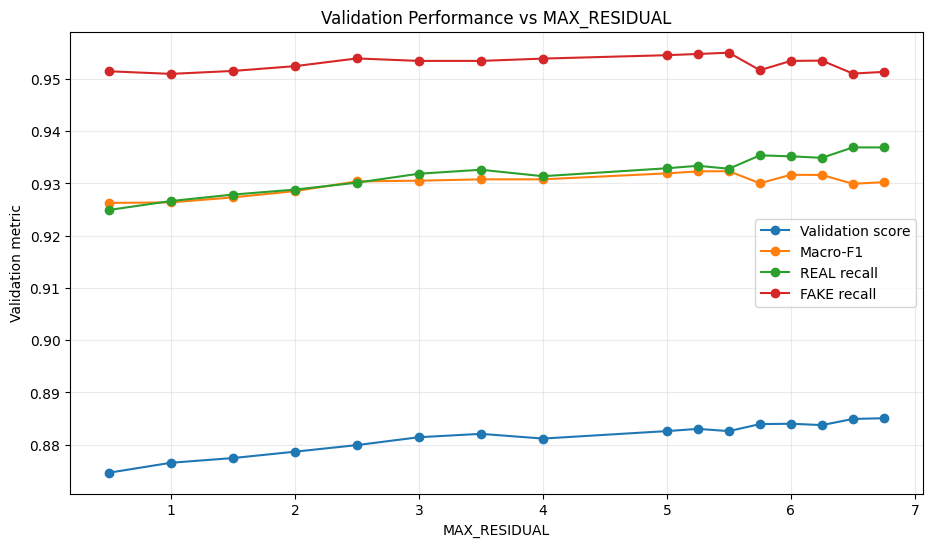

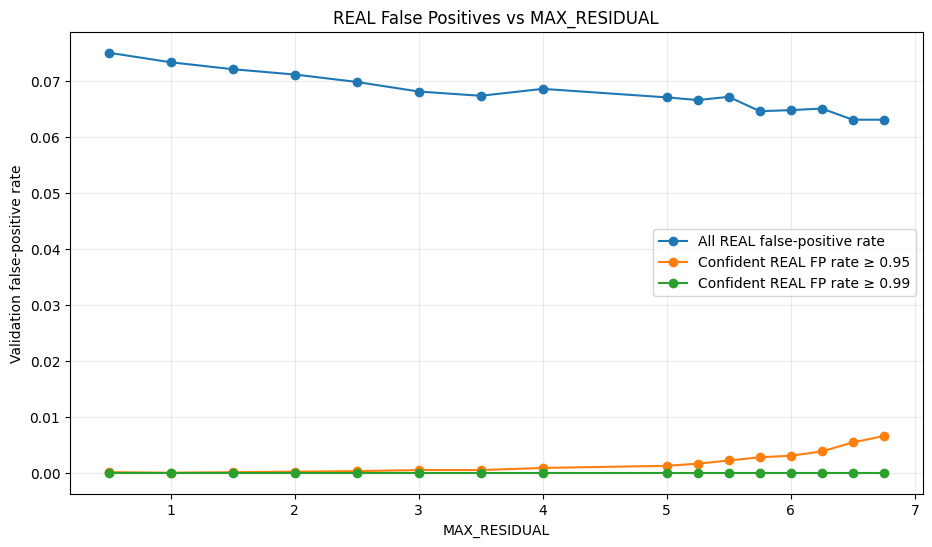

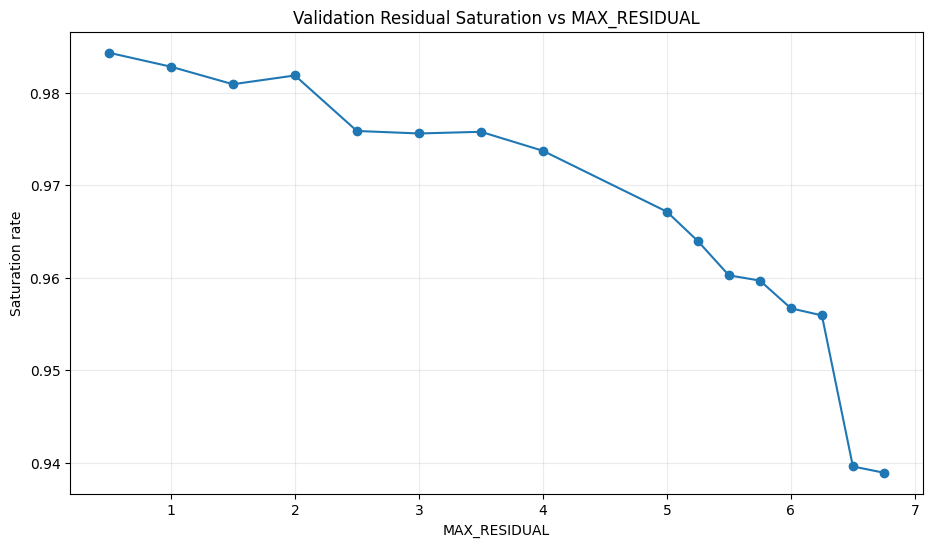

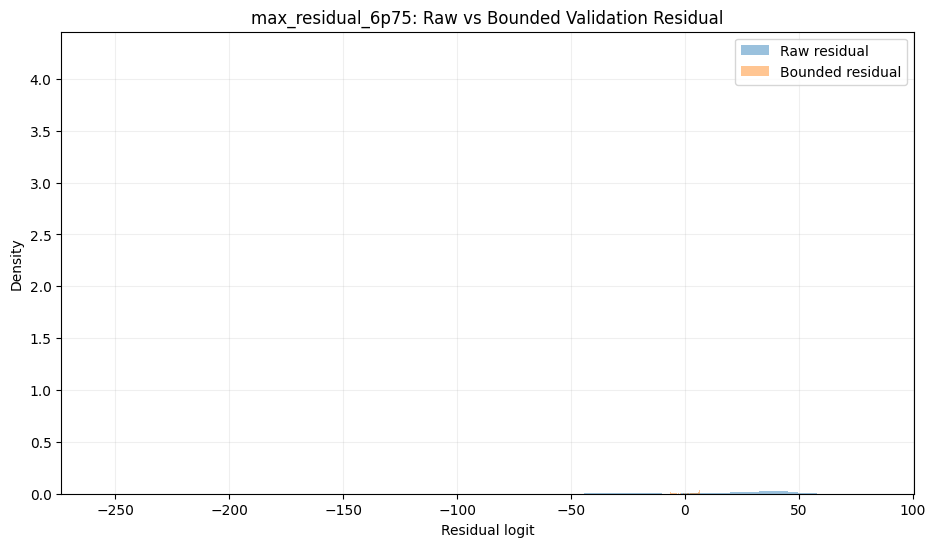

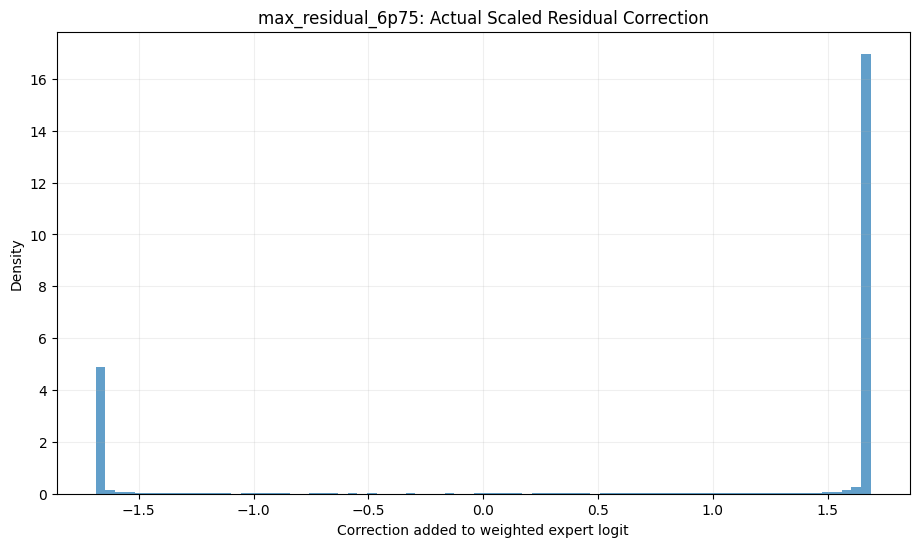

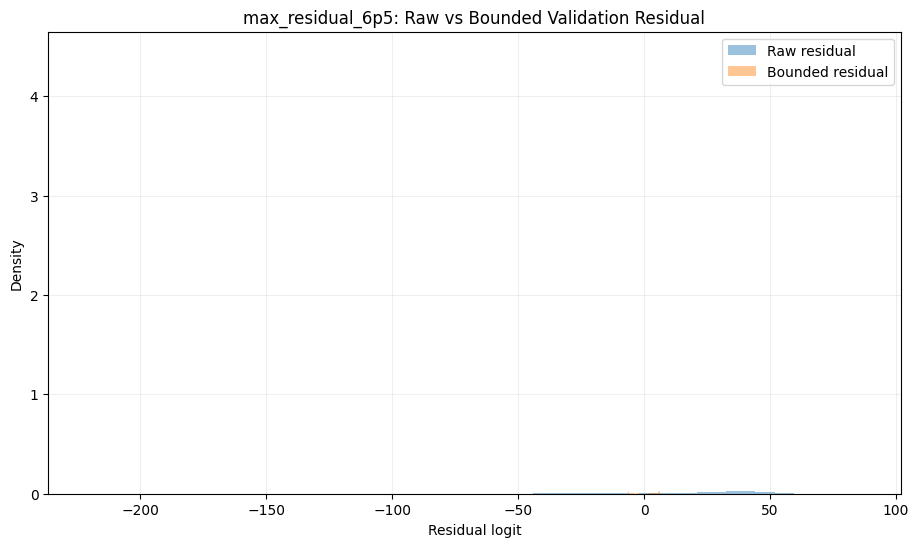

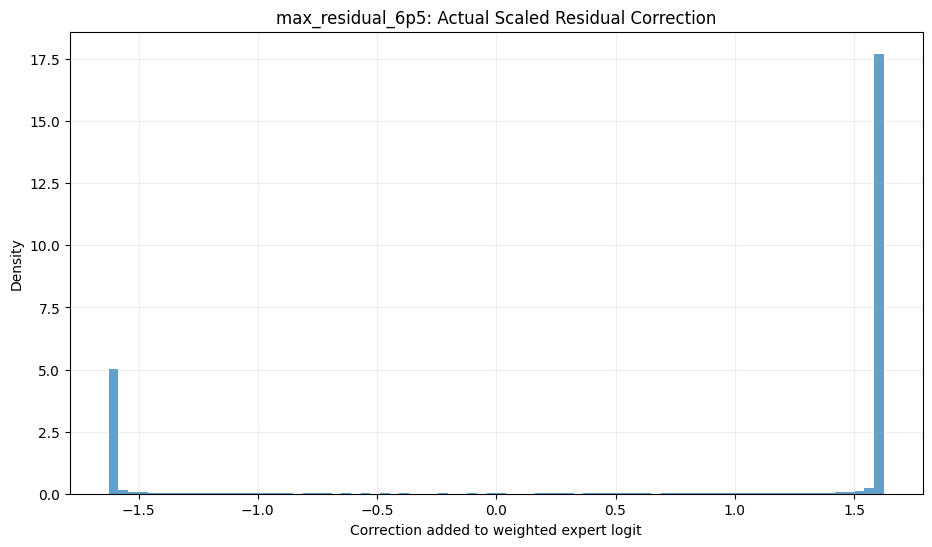

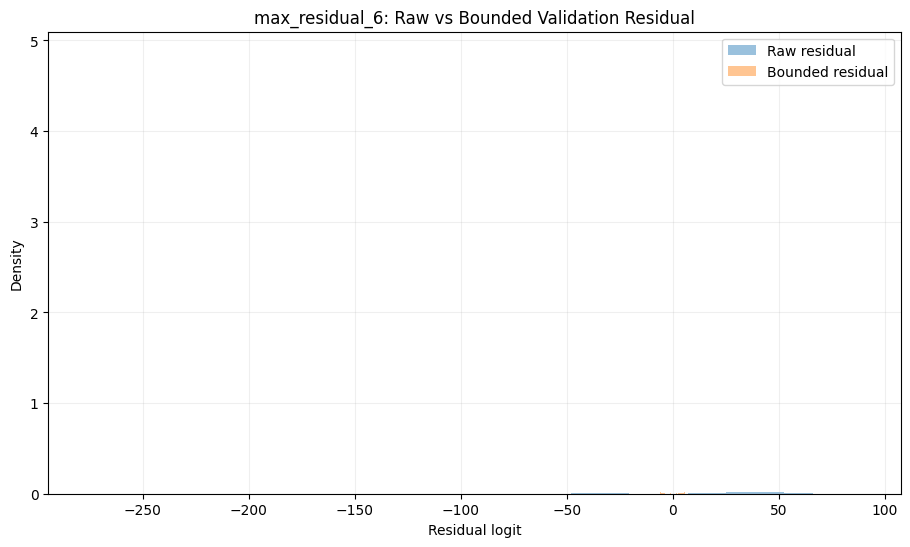

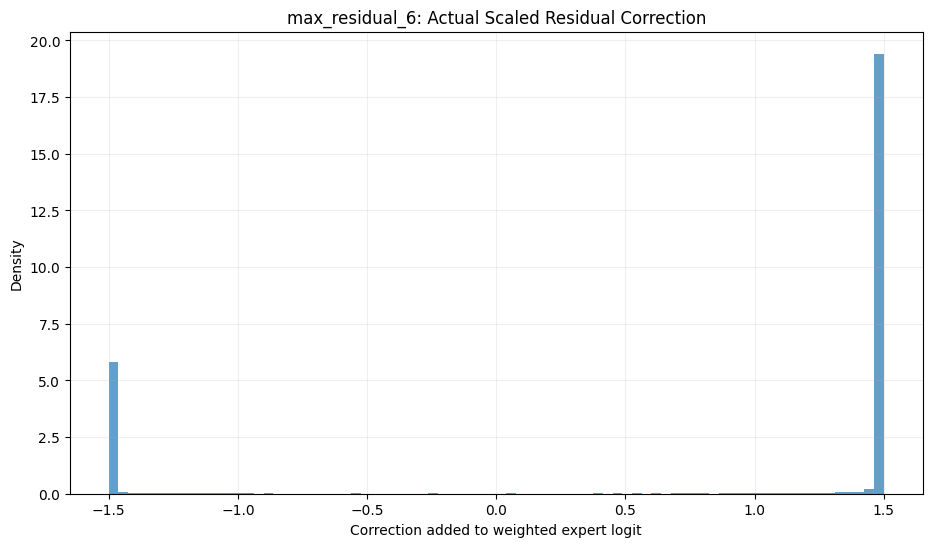

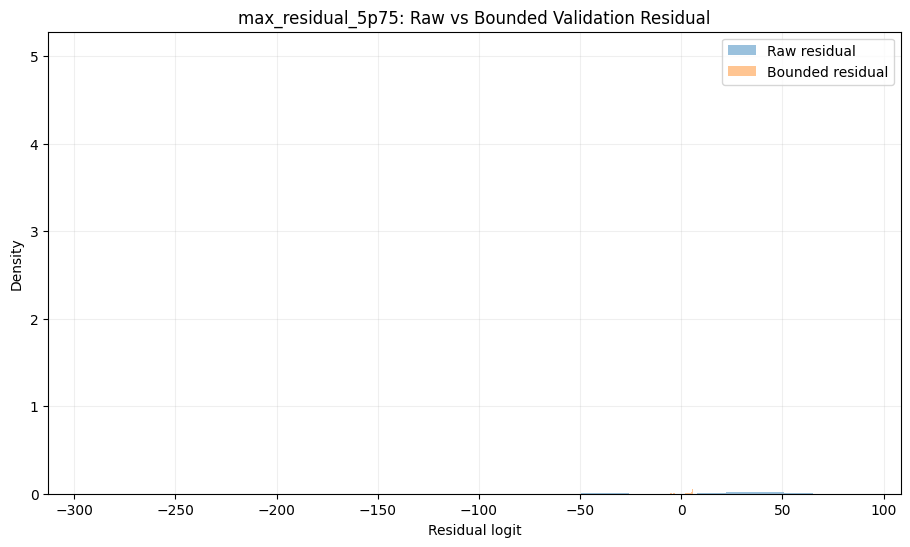

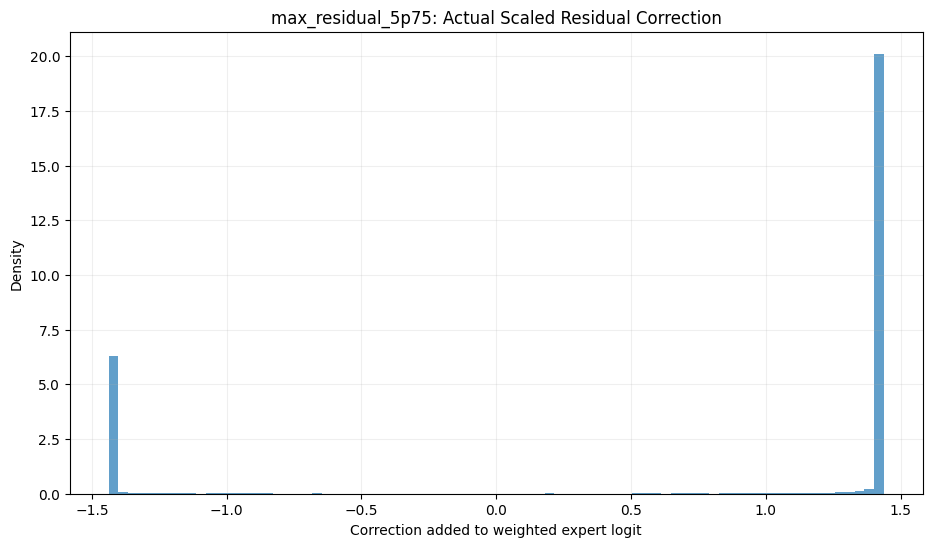

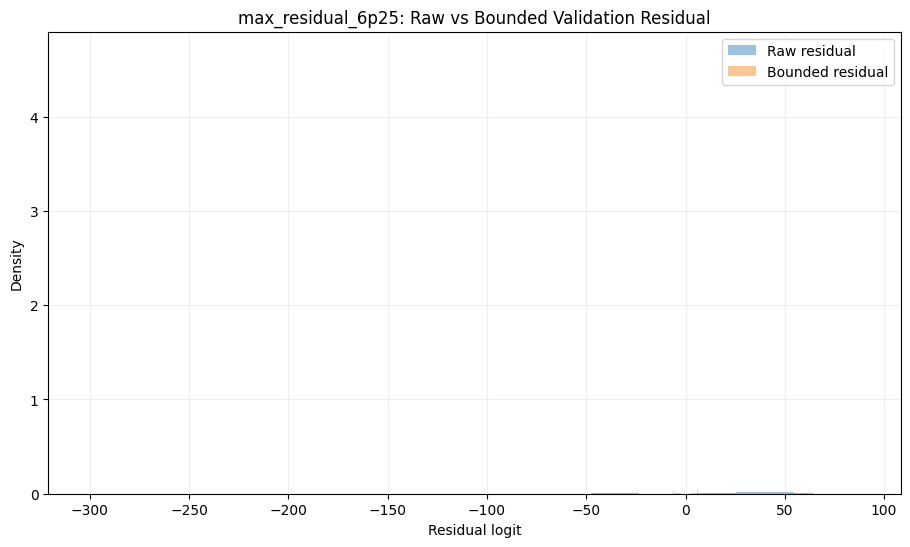

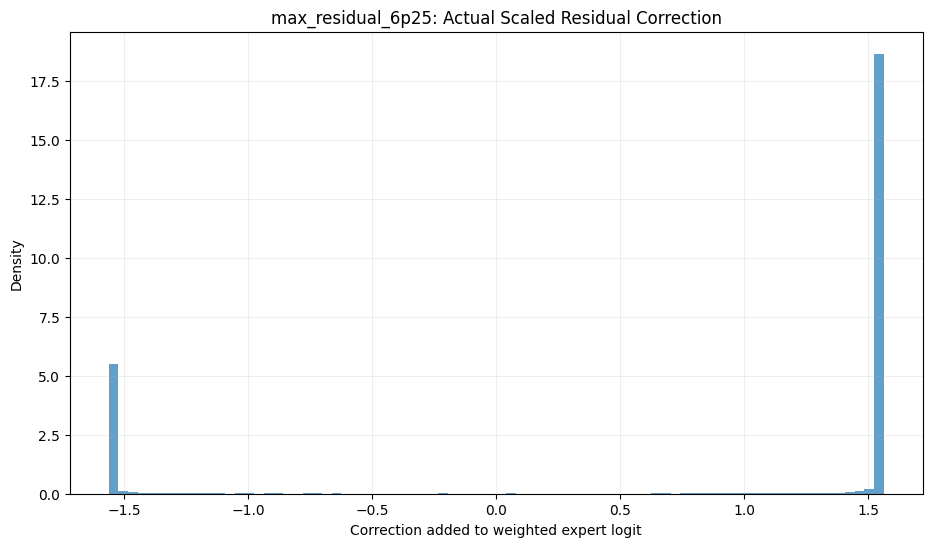

In [23]:
# CELL 19 — PERFORMANCE, FALSE-POSITIVE, AND SATURATION PLOTS
import matplotlib.pyplot as plt
bounded_summary = (
    all_validation_summary[
        all_validation_summary[
            "variant"
        ] != "unbounded"
    ]
    .sort_values(
        "max_residual"
    )
)


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "validation_score"
    ],
    marker="o",
    label="Validation score",
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "macro_f1"
    ],
    marker="o",
    label="Macro-F1",
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "real_recall"
    ],
    marker="o",
    label="REAL recall",
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "fake_recall"
    ],
    marker="o",
    label="FAKE recall",
)

plt.xlabel(
    "MAX_RESIDUAL"
)

plt.ylabel(
    "Validation metric"
)

plt.title(
    "Validation Performance vs MAX_RESIDUAL"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "real_false_positive_rate"
    ],
    marker="o",
    label=(
        "All REAL false-positive rate"
    ),
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "confident_real_fp_95_rate"
    ],
    marker="o",
    label=(
        "Confident REAL FP rate ≥ 0.95"
    ),
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "confident_real_fp_99_rate"
    ],
    marker="o",
    label=(
        "Confident REAL FP rate ≥ 0.99"
    ),
)

plt.xlabel(
    "MAX_RESIDUAL"
)

plt.ylabel(
    "Validation false-positive rate"
)

plt.title(
    "REAL False Positives vs MAX_RESIDUAL"
)

plt.legend()
plt.grid(alpha=0.25)
plt.show()


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    bounded_summary[
        "max_residual"
    ],
    bounded_summary[
        "saturation_rate"
    ],
    marker="o",
)

plt.xlabel(
    "MAX_RESIDUAL"
)

plt.ylabel(
    "Saturation rate"
)

plt.title(
    "Validation Residual Saturation vs MAX_RESIDUAL"
)

plt.grid(alpha=0.25)
plt.show()


top_candidate_names = (
    all_validation_summary[
        all_validation_summary[
            "variant"
        ] != "unbounded"
    ]
    .head(5)[
        "variant"
    ]
    .tolist()
)


for candidate_name in (
    top_candidate_names
):
    result = trained_variants[
        candidate_name
    ]

    diagnostics = result[
        "validation_diagnostics"
    ]

    raw_values = diagnostics[
        "raw_residual_logit"
    ]

    bounded_values = diagnostics[
        "bounded_residual_logit"
    ]

    scaled_values = diagnostics[
        "scaled_residual_contribution"
    ]

    plt.figure(
        figsize=(11, 6)
    )

    plt.hist(
        raw_values,
        bins=80,
        density=True,
        alpha=0.45,
        label="Raw residual",
    )

    plt.hist(
        bounded_values,
        bins=80,
        density=True,
        alpha=0.45,
        label="Bounded residual",
    )

    plt.title(
        f"{candidate_name}: Raw vs Bounded Validation Residual"
    )

    plt.xlabel(
        "Residual logit"
    )

    plt.ylabel(
        "Density"
    )

    plt.legend()
    plt.grid(alpha=0.20)
    plt.show()


    plt.figure(
        figsize=(11, 6)
    )

    plt.hist(
        scaled_values,
        bins=80,
        density=True,
        alpha=0.70,
    )

    plt.title(
        f"{candidate_name}: Actual Scaled Residual Correction"
    )

    plt.xlabel(
        "Correction added to weighted expert logit"
    )

    plt.ylabel(
        "Density"
    )

    plt.grid(alpha=0.20)
    plt.show()


In [25]:
# CELL 20 — SELECT THE BEST-PERFORMANCE AND SAFER NEAR-BEST CANDIDATES

bounded_candidates = (
    all_validation_summary[
        all_validation_summary[
            "variant"
        ] != "unbounded"
    ]
    .copy()
)

best_performance_row = (
    bounded_candidates
    .sort_values(
        [
            "validation_score",
            "macro_f1",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

highest_validation_score = float(
    best_performance_row[
        "validation_score"
    ]
)

near_best_candidates = (
    bounded_candidates[
        bounded_candidates[
            "validation_score"
        ]
        >= (
            highest_validation_score
            - NEAR_BEST_SCORE_TOLERANCE
        )
    ]
    .copy()
)

recommended_safe_row = (
    near_best_candidates
    .sort_values(
        [
            "confident_real_fp_95_rate",
            "real_false_positive_rate",
            "saturation_rate",
            "max_residual",
        ],
        ascending=[
            True,
            True,
            True,
            True,
        ],
    )
    .iloc[0]
)

BEST_PERFORMANCE_VARIANT = str(
    best_performance_row[
        "variant"
    ]
)

RECOMMENDED_SAFE_VARIANT = str(
    recommended_safe_row[
        "variant"
    ]
)

print(
    "Highest validation-performance candidate"
)

display(
    best_performance_row
    .to_frame()
    .T
)

print(
    "Recommended safer near-best candidate"
)

display(
    recommended_safe_row
    .to_frame()
    .T
)

print(
    "Near-best score tolerance:",
    NEAR_BEST_SCORE_TOLERANCE,
)


Highest validation-performance candidate


,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
0,max_residual_6p75,6.75,0.8175,0.885059,0.947913,0.930234,0.936888,0.951342,0.981107,0.936446,...,-175.702377,31.37026,59.575558,-6.75,6.74876,6.75,1.648905,1.6875,0.938916,6


Recommended safer near-best candidate


,variant,max_residual,threshold,validation_score,accuracy,macro_f1,real_recall,fake_recall,auc,worst_scenario,...,raw_residual_p01,raw_residual_p50,raw_residual_p99,bounded_residual_p01,bounded_residual_p50,bounded_residual_p99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,best_epoch
9,max_residual_3p5,3.5,0.7,0.882065,0.948499,0.930775,0.932611,0.953441,0.979892,0.93245,...,-171.634262,23.475334,46.927155,-3.5,3.49999,3.5,0.86733,0.875,0.97576,14


Near-best score tolerance: 0.005


In [26]:
# CELL 21 — EVALUATE EVERY CANDIDATE ON ORIGINAL HELD-OUT SPLITS

def evaluate_variant(
    result,
    split_name,
):
    data = prep(
        split_name
    )

    (
        probabilities,
        weights,
        diagnostics,
    ) = infer_model(
        result["model"],
        data,
    )

    threshold = float(
        result["threshold"]
    )

    current_metrics = metrics(
        data["y"],
        probabilities,
        threshold,
    )

    predictions = current_metrics[
        "pred"
    ]

    labels = data[
        "y"
    ].astype(int)

    real_false_positive_mask = (
        (labels == 0)
        & (predictions == 1)
    )

    confident_fp_95_mask = (
        real_false_positive_mask
        & (probabilities >= 0.95)
    )

    confident_fp_99_mask = (
        real_false_positive_mask
        & (probabilities >= 0.99)
    )

    bounded_residual = diagnostics[
        "bounded_residual_logit"
    ]

    if result[
        "max_residual"
    ] is None:
        saturation_rate = np.nan

    else:
        saturation_rate = float(
            (
                np.abs(
                    bounded_residual
                )
                >= (
                    0.95
                    * float(
                        result[
                            "max_residual"
                        ]
                    )
                )
            ).mean()
        )

    return {
        "variant":
            result["name"],

        "max_residual":
            (
                np.nan
                if result[
                    "max_residual"
                ] is None
                else float(
                    result[
                        "max_residual"
                    ]
                )
            ),

        "split":
            split_name,

        "threshold":
            threshold,

        **{
            key: value
            for key, value
            in current_metrics.items()
            if key != "pred"
        },

        "real_false_positives":
            int(
                real_false_positive_mask.sum()
            ),

        "confident_real_fp_95":
            int(
                confident_fp_95_mask.sum()
            ),

        "confident_real_fp_99":
            int(
                confident_fp_99_mask.sum()
            ),

        "mean_abs_scaled_residual":
            float(
                np.abs(
                    diagnostics[
                        "scaled_residual_contribution"
                    ]
                ).mean()
            ),

        "maximum_abs_scaled_residual":
            float(
                np.abs(
                    diagnostics[
                        "scaled_residual_contribution"
                    ]
                ).max()
            ),

        "saturation_rate":
            saturation_rate,

        "frequency_gate":
            float(
                weights[
                    :,
                    0,
                ].mean()
            ),

        "original_spatial_gate":
            float(
                weights[
                    :,
                    1,
                ].mean()
            ),

        "auxiliary_spatial_gate":
            float(
                weights[
                    :,
                    2,
                ].mean()
            ),
    }


evaluation_rows = []

for result in (
    trained_variants.values()
):
    for split_name in (
        "mixed_test",
        "ff_test",
        "celeb_test",
        "phone_test",
    ):
        evaluation_rows.append(
            evaluate_variant(
                result,
                split_name,
            )
        )


heldout_results = pd.DataFrame(
    evaluation_rows
)

display(
    heldout_results.sort_values(
        [
            "split",
            "macro_f1",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

heldout_results.to_csv(
    OUTPUT_DIR
    / "max_residual_all_heldout_results.csv",
    index=False,
)


,variant,max_residual,split,threshold,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,real_false_positives,confident_real_fp_95,confident_real_fp_99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate,frequency_gate,original_spatial_gate,auxiliary_spatial_gate
42,max_residual_6,6.00,celeb_test,0.7975,0.720833,0.689288,0.590284,0.788291,0.603300,0.77960,0.751733,3967,403,1,1.427453,1.5000,0.866967,0.001669,0.423283,0.575047
58,max_residual_6p25,6.25,celeb_test,0.8100,0.720133,0.689145,0.590998,0.787292,0.606600,0.77690,0.752815,3934,465,1,1.489413,1.5625,0.871667,0.002023,0.410903,0.587074
50,max_residual_5p5,5.50,celeb_test,0.7800,0.724967,0.688657,0.582334,0.794981,0.575200,0.79985,0.749621,4248,324,1,1.309961,1.3750,0.870233,0.002367,0.505019,0.492614
46,max_residual_5p25,5.25,celeb_test,0.7700,0.720600,0.688100,0.587419,0.788781,0.596700,0.78255,0.748815,4033,284,0,1.257286,1.3125,0.884933,0.001272,0.432276,0.566452
38,max_residual_5,5.00,celeb_test,0.7650,0.721467,0.688056,0.585968,0.790145,0.591300,0.78655,0.748571,4087,240,0,1.204880,1.2500,0.900367,0.001095,0.431378,0.567527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,max_residual_5,5.00,phone_test,0.7650,0.946970,0.486381,0.972763,0.000000,0.946970,0.00000,NaN,14,0,0,1.211525,1.2500,0.931818,0.272965,0.024990,0.702045
55,max_residual_5p75,5.75,phone_test,0.7825,0.946970,0.486381,0.972763,0.000000,0.946970,0.00000,NaN,14,0,0,1.408745,1.4375,0.931818,0.289122,0.053874,0.657004
43,max_residual_6,6.00,phone_test,0.7975,0.939394,0.484375,0.968750,0.000000,0.939394,0.00000,NaN,16,0,0,1.464120,1.5000,0.916667,0.281407,0.045843,0.672750
11,max_residual_1,1.00,phone_test,0.5800,0.931818,0.482353,0.964706,0.000000,0.931818,0.00000,NaN,18,0,0,0.245924,0.2500,0.965909,0.286636,0.001185,0.712179


In [28]:
# CELL 22 — ORIGINAL ACCEPTANCE GATES FOR EVERY CANDIDATE

acceptance_rows = []

for variant_name_value in (
    trained_variants
):
    candidate_results = (
        heldout_results[
            heldout_results[
                "variant"
            ]
            == variant_name_value
        ]
        .set_index(
            "split"
        )
    )

    checks = {
        "FF++ macro-F1 >= .90":
            candidate_results.loc[
                "ff_test",
                "macro_f1",
            ] >= 0.90,

        "FF++ real recall >= .88":
            candidate_results.loc[
                "ff_test",
                "real_recall",
            ] >= 0.88,

        "FF++ fake recall >= .92":
            candidate_results.loc[
                "ff_test",
                "fake_recall",
            ] >= 0.92,

        "CelebDF AUC >= .76":
            candidate_results.loc[
                "celeb_test",
                "auc",
            ] >= 0.76,

        "CelebDF real recall >= .70":
            candidate_results.loc[
                "celeb_test",
                "real_recall",
            ] >= 0.70,

        "CelebDF fake recall >= .70":
            candidate_results.loc[
                "celeb_test",
                "fake_recall",
            ] >= 0.70,

        "Phone real recall >= .80":
            candidate_results.loc[
                "phone_test",
                "real_recall",
            ] >= 0.80,
    }

    acceptance_rows.append({
        "variant":
            variant_name_value,

        "passed":
            int(
                sum(
                    checks.values()
                )
            ),

        "total":
            len(checks),

        **checks,
    })


acceptance_gates = pd.DataFrame(
    acceptance_rows
).sort_values(
    [
        "passed",
        "variant",
    ],
    ascending=[
        False,
        True,
    ],
)

display(
    acceptance_gates
)

acceptance_gates.to_csv(
    OUTPUT_DIR
    / "max_residual_acceptance_gates.csv",
    index=False,
)


,variant,passed,total,FF++ macro-F1 >= .90,FF++ real recall >= .88,FF++ fake recall >= .92,CelebDF AUC >= .76,CelebDF real recall >= .70,CelebDF fake recall >= .70,Phone real recall >= .80
15,max_residual_6p5,5,7,True,True,True,False,False,True,True
16,max_residual_6p75,5,7,True,True,True,False,False,True,True
1,max_residual_0p5,4,7,True,False,True,False,False,True,True
2,max_residual_1,4,7,True,False,True,False,False,True,True
3,max_residual_1p5,4,7,True,False,True,False,False,True,True
4,max_residual_2,4,7,True,False,True,False,False,True,True
5,max_residual_2p5,4,7,True,False,True,False,False,True,True
6,max_residual_3,4,7,True,False,True,False,False,True,True
7,max_residual_3p5,4,7,True,False,True,False,False,True,True
8,max_residual_4,4,7,True,False,True,False,False,True,True


In [29]:
# CELL 23 — TOP-CANDIDATE COMPARISON

top_variant_names = list(
    dict.fromkeys([
        "unbounded",
        BEST_PERFORMANCE_VARIANT,
        RECOMMENDED_SAFE_VARIANT,
    ])
)

top_candidate_comparison = (
    heldout_results[
        heldout_results[
            "variant"
        ].isin(
            top_variant_names
        )
    ]
    .copy()
)

display(
    top_candidate_comparison[
        [
            "variant",
            "max_residual",
            "split",
            "threshold",
            "accuracy",
            "macro_f1",
            "real_recall",
            "fake_recall",
            "auc",
            "real_false_positives",
            "confident_real_fp_95",
            "confident_real_fp_99",
            "mean_abs_scaled_residual",
            "maximum_abs_scaled_residual",
            "saturation_rate",
        ]
    ].sort_values(
        [
            "split",
            "variant",
        ]
    )
)

top_candidate_comparison.to_csv(
    OUTPUT_DIR
    / "max_residual_top_candidate_comparison.csv",
    index=False,
)


,variant,max_residual,split,threshold,accuracy,macro_f1,real_recall,fake_recall,auc,real_false_positives,confident_real_fp_95,confident_real_fp_99,mean_abs_scaled_residual,maximum_abs_scaled_residual,saturation_rate
30,max_residual_3p5,3.50,celeb_test,0.7000,0.717533,0.684692,0.592200,0.780200,0.746634,4078,78,0,0.849954,0.875000,0.922400
66,max_residual_6p75,6.75,celeb_test,0.8175,0.710333,0.685321,0.642600,0.744200,0.756320,3574,591,1,1.554190,1.687500,0.786633
2,unbounded,NaN,celeb_test,0.7975,0.727433,0.687185,0.553100,0.814600,0.752857,4469,3796,2965,5.745987,19.341791,NaN
29,max_residual_3p5,3.50,ff_test,0.7000,0.954331,0.912001,0.868661,0.969461,0.984047,518,8,0,0.869672,0.875000,0.983826
65,max_residual_6p75,6.75,ff_test,0.8175,0.952047,0.909075,0.881339,0.964535,0.984029,468,61,2,1.659719,1.687500,0.955206
1,unbounded,NaN,ff_test,0.7975,0.952238,0.908553,0.869675,0.966819,0.981928,514,411,295,11.111938,27.421127,NaN
28,max_residual_3p5,3.50,mixed_test,0.7000,0.939032,0.935843,0.966341,0.922959,0.983672,207,2,0,0.861678,0.875000,0.960058
64,max_residual_6p75,6.75,mixed_test,0.8175,0.941924,0.938764,0.964553,0.928606,0.986179,218,10,0,1.630502,1.687500,0.914633
0,unbounded,NaN,mixed_test,0.7975,0.943671,0.940699,0.971382,0.927361,0.989872,176,83,28,6.986020,38.318344,NaN
31,max_residual_3p5,3.50,phone_test,0.7000,0.950758,0.487379,0.950758,0.000000,NaN,13,0,0,0.848258,0.875000,0.909091
